In [2]:
print("Started................")

Started................


In this Notebook, 

I am trying to use BDR (Bi-Dimensional Regression) on our Sketchmaps.
Rather than being a statistic, BDR is more like a framework, where multiple statistical measures are used. #

These statistical measures are as follows:

1. r -> Correlation coefficient (This shows how the map overall looks like)
2. R^2 -> Covariance (How well is everything placed in the sketchmap)
3. DI -> Distortion Index (from 0 to 100, shows how messy a drawing is, or how distorted is a sketchmap.)
4. Alpha 1 -> Horizontal shift (did the person shift all the building in the east?) Negative value indicates West
5. Alpha 2 -> Vertical shift (did the person shift all the buildings in the North? ) Negative value indicates south
6. Theta -> Rotation Angle (shows whether the whole sketchmap is rotated by a certail angle)
7. phi -> scale (shows whether the things in sketchmap are larger or smaller than the basemap.)

These measures constitutes BDR (Bi - Dimensional Regression).

BDR always works on 2 points or in this case polygons (which are also being denoted by points in this case). 

Now, these measures are ran individualy on a pair (one point in Basemap and another in sketchmap) and then all of these values are averaged by all of the buildings in the sketchmap. 




In [3]:
import geopandas as gpd
import json
import matplotlib.pyplot as plt

    id isRoute feat_type  selected  aligned    otype  RouteSeqOrder  missing  \
24  24     NaN  Landmark     False     True  Polygon            NaN      NaN   
25  25     NaN  Landmark     False     True  Polygon            NaN      NaN   
26  26     NaN  Landmark     False     True  Polygon            NaN      NaN   
27  27     NaN  Landmark     False     True  Polygon            NaN      NaN   
28  28     NaN  Landmark     False     True  Polygon            NaN      NaN   
29  29     NaN  Landmark     False     True  Polygon            NaN      NaN   
30  30     NaN  Landmark     False     True  Polygon            NaN      NaN   
31  31     NaN  Landmark     False     True  Polygon            NaN      NaN   
32  32     NaN  Landmark     False     True  Polygon            NaN      NaN   
33  33     NaN  Landmark     False     True  Polygon            NaN      NaN   

                                             geometry  
24  POLYGON ((216.5 475.8, 238.5 476.3, 243 525.3,...  
25  POL

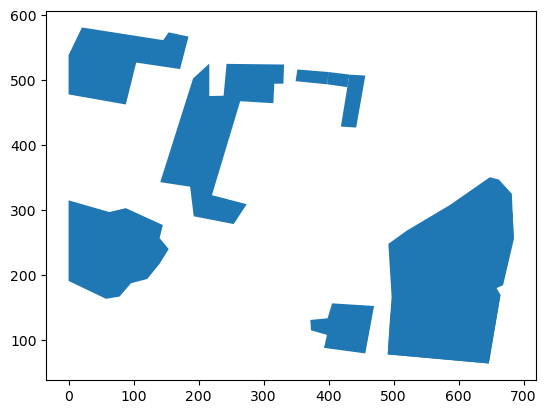

In [4]:
bsm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/basemap.jpg.geojson")
bsm_landmarks  = bsm_feat[bsm_feat['feat_type'] == 'Landmark']


print(bsm_landmarks)
bsm_landmarks.plot()
ax = plt.gca()
ax.set_aspect('equal')

    id  sid isRoute feat_type  selected  aligned    otype  \
22  22  S22     NaN  Landmark     False     True  Polygon   
23  23  S23     NaN  Landmark     False     True  Polygon   
24  24  S24     NaN  Landmark     False     True  Polygon   
25  25  S25     NaN  Landmark     False     True  Polygon   
26  26  S26     NaN  Landmark     False     True  Polygon   
27  27  S27     NaN  Landmark     False     True  Polygon   
28  28  S28     NaN  Landmark     False     True  Polygon   
29  29  S29     NaN  Landmark     False     True  Polygon   
30  30  S30     NaN  Landmark     False     True  Polygon   
31  31  S31     NaN  Landmark     False     True  Polygon   
32  32  S32     NaN  Landmark     False    False  Polygon   

    SketchRouteSeqOrder                                           geometry  
22                  NaN  POLYGON ((58.727 467.5, 94.717 475, 96.217 424...  
23                  NaN  POLYGON ((142.7 397.01, 172.61 392, 190.6 392,...  
24                  NaN  POLYGON ((2

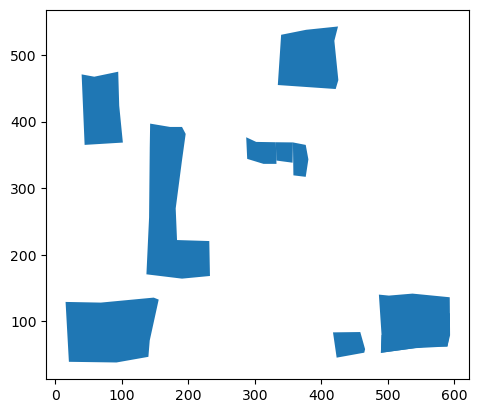

In [5]:
skm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/sketchMap1.JPG.geojson")



skm_landmarks = skm_feat[skm_feat['feat_type'] == 'Landmark']
print(skm_landmarks)
skm_landmarks.plot()
ax = plt.gca()
ax.set_aspect('equal')

In [6]:
with open('./datasets/alignm/alignment.json', 'r') as file:
    align = json.load(file)


print(align['sketchMap1.JPG'])

sketchmap1_align = align['sketchMap1.JPG']

{'1': {'BaseAlign': {'0': [0]}, 'SketchAlign': {'0': ['S0']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '2': {'BaseAlign': {'0': [1]}, 'SketchAlign': {'0': ['S1']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '3': {'BaseAlign': {'0': [2]}, 'SketchAlign': {'0': ['S2']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '4': {'BaseAlign': {'0': [3]}, 'SketchAlign': {'0': ['S3']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '5': {'BaseAlign': {'0': [4]}, 'SketchAlign': {'0': ['S4']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '6': {'BaseAlign': {'0': [6]}, 'SketchAlign': {'0': ['S5']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '7': {'BaseAlign': {'0': [7]}, 'SketchAlign': {'0': ['S6']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '8': {'BaseAlign': {'0': [8]}, 'SketchAlign': {'0': ['S7']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '9': {'BaseAlig

I have three files now: 
        1. Basemap GeoJSON file
        2. Sketchmap GeoJSON file
        3. Alignment JSON file

Alignment file contains how I the landmarks in Basemap are connected to Sketchmap. 

So, there is a key in Sketchmap GeoJSON 'sid' which is mentioned in Alignment file and also an id of Basemap.

This will help us match Landmarks in these files. 

In [7]:
from skimage import transform 
import numpy as np
import sys


base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum":
        continue

    base_indices = value['BaseAlign']['0']
    sketch_sids = value['SketchAlign']['0']

    s_id = sketch_sids[0]

    
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_id]
    b_feat = bsm_landmarks[bsm_landmarks['id'].isin(base_indices)]

    if not s_feat.empty and not b_feat.empty:
        s_centroid = s_feat.geometry.representative_point().values[0]
        sketch_pts.append([s_centroid.x, s_centroid.y])

        b_centroids = b_feat.geometry.representative_point()
        mean_x = b_centroids.x.mean()
        mean_y = b_centroids.y.mean()
        base_pts.append([mean_x, mean_y])
#We are using the representative point of the geometry to get a single point for each feature,
#and then we average the x and y coordinates because of generalization of multiple features in teh base map.
#This way we can get a single point for multiple features in the basemap which then aligns with single features in the sketchmap.




X = np.array(base_pts)
Y = np.array(sketch_pts)

tform = transform.SimilarityTransform()
tform.estimate(X,Y)

print("BDR Complete")
print(f" {len(X)} valid alignment pairs.")
print(f" Scale: {tform.scale:.4f}")
print(f" Rotation: {np.degrees(tform.rotation):.2f}")

BDR Complete
 10 valid alignment pairs.
 Scale: 0.8745
 Rotation: 2.01


In the cell above, 

I have taken three lists: 
1. base_pts (stores the points from basemap)
2. sketch_pts (stores the points from sketchmap) and 
3. pair_labels (stores the pairs which are common in basemap and sketchmap)


Then, extract the pairs from the alignment file. 
Where, the common landmarks are matched using, 

'id' from basemap
'sid' from sketchmap

Now, we extract where both id and sid are not empty, giving us the common polygons. 
After this, I take the building id from basemap and sketchmap (they are already aligned) and draw a centroid using the geometry of the buildings in sketchmap.

For basemap, we use representative point, which makes sure the centre point of our building is always inside the building and not out. Since, the buildings in the basemap can have complex shapes, which might include a lot of corners or vertices. 


Then, we store all those points from basemap in X (ground truth), which is the independent variable and 
we store all the points from sketchmap in Y (drawn by user), is the dependent variable. 

WE store them into numpy array, because that is the acceptable format for BDR.


Then we use the SimilarityTransfrom function, which matches how well these two maps match, but movement, rotation and scaling the basemap is allowed to make it fit the sketchmap.


After that, the function find the best rotation, the best scale and the best shift, which results in the smallest possible distrance betweeen the ground truth and the corresponding sketchmaps.

# BDR

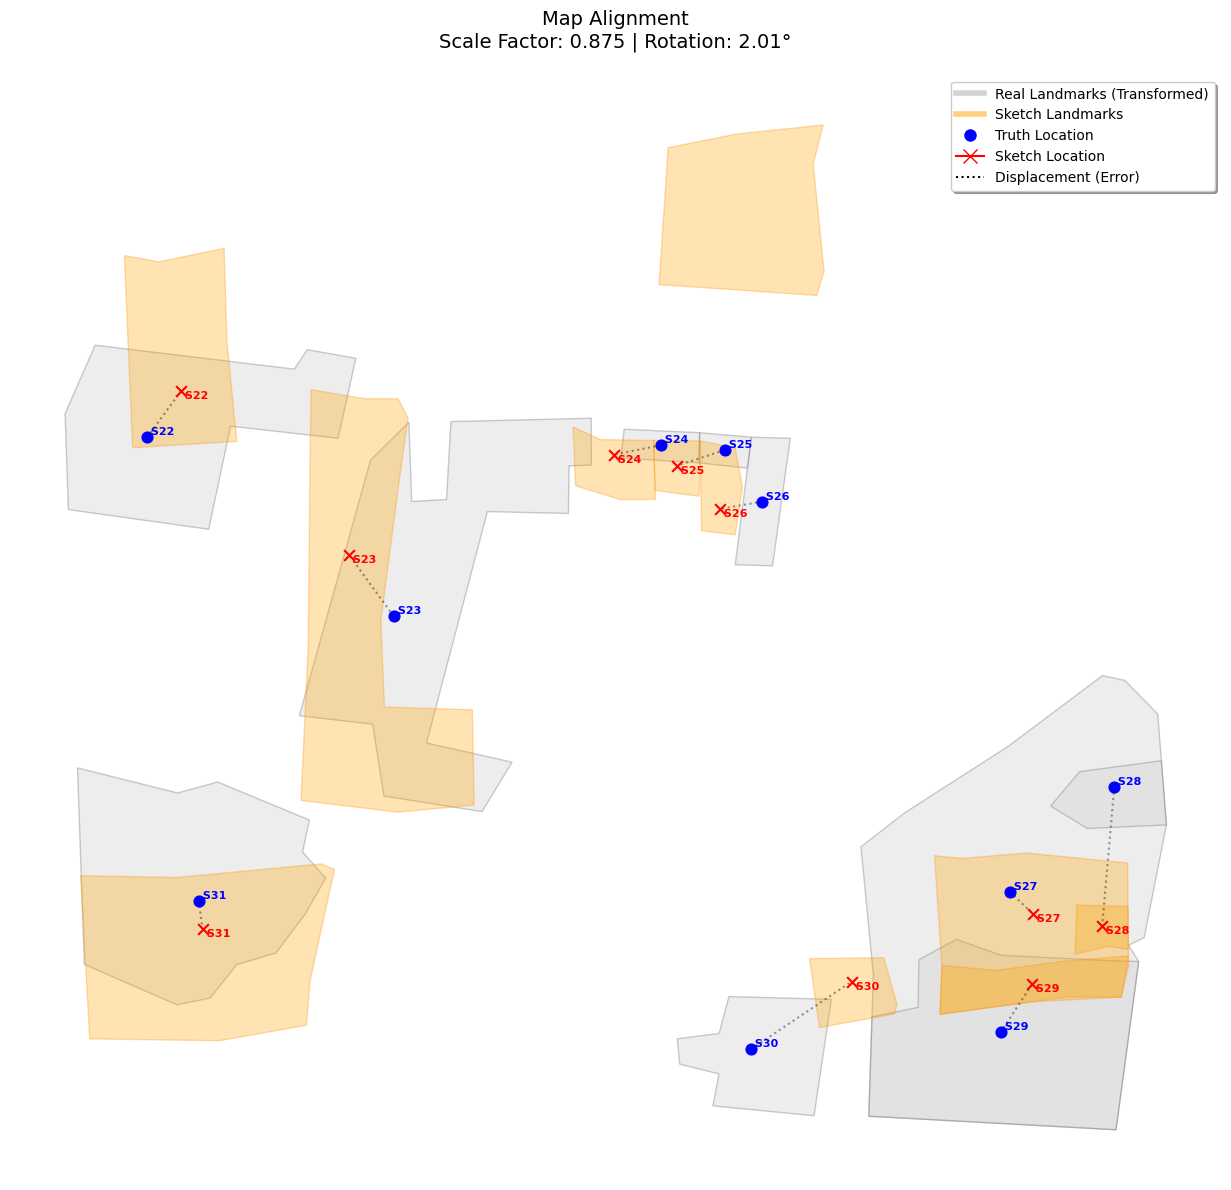

In [8]:
import matplotlib.pyplot as plt
from skimage import transform
from shapely.affinity import affine_transform
import numpy as np

# --- 1. DATA PROCESSING & SYNCHRONIZATION ---
base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    b_feats = bsm_landmarks[bsm_landmarks['id'].isin(b_indices)]
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_sid]
    
    if not s_feat.empty and not b_feats.empty:
        # Use representative_point to ensure dots stay inside building footprints
        b_point = b_feats.geometry.representative_point()
        base_pts.append([b_point.x.mean(), b_point.y.mean()])
        
        s_point = s_feat.geometry.representative_point().values[0]
        sketch_pts.append([s_point.x, s_point.y])
        pair_labels.append(s_sid) 

X = np.array(base_pts)
Y = np.array(sketch_pts)

# --- 2. BIDIMENSIONAL REGRESSION ---
tform = transform.SimilarityTransform()
tform.estimate(X, Y)
predicted_Y = tform(X)

# --- 3. GEOMETRY TRANSFORMATION ---
# Move the Real Landmarks into Sketch Space so they overlap for the plot
m = tform.params
matrix = [m[0,0], m[0,1], m[1,0], m[1,1], m[0,2], m[1,2]]
bsm_transformed = bsm_landmarks.copy()
bsm_transformed['geometry'] = bsm_transformed['geometry'].apply(lambda x: affine_transform(x, matrix))

# IMPORTANT: Strip CRS to prevent "aspect must be finite" error
bsm_transformed.crs = None
skm_landmarks.crs = None

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_aspect('equal')

# Plot Polygons
bsm_transformed.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.4, label='Real World (Projected)')
skm_landmarks.plot(ax=ax, color='orange', edgecolor='darkorange', alpha=0.3, label='User Sketch')

# Plot Dots
# We plot the first one with a label for the legend, then loop the rest
ax.scatter(predicted_Y[:, 0], predicted_Y[:, 1], color='blue', s=60, marker='o', 
           label='Truth Anchor (Blue)', zorder=5)
ax.scatter(Y[:, 0], Y[:, 1], color='red', s=60, marker='x', 
           label='Sketch Anchor (Red)', zorder=5)

# Plot Labels and Connectors
for i in range(len(Y)):
    label = pair_labels[i]
    
    # Label the Blue Dot
    ax.text(predicted_Y[i, 0], predicted_Y[i, 1], f" {label}", 
            color='blue', fontsize=8, fontweight='bold', va='bottom')
    
    # Label the Red Dot
    ax.text(Y[i, 0], Y[i, 1], f" {label}", 
            color='red', fontsize=8, fontweight='bold', va='top')
    
    # Connector line (Error Vector)
    line, = ax.plot([predicted_Y[i, 0], Y[i, 0]], [predicted_Y[i, 1], Y[i, 1]], 
                    color='black', linestyle=':', alpha=0.4, zorder=4)

# Formatting
plt.title(f"Map Alignment\nScale Factor: {tform.scale:.3f} | Rotation: {np.degrees(tform.rotation):.2f}°", 
          fontsize=14, pad=20)

# Manually handle legend because geopandas.plot and ax.scatter work differently
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='lightgray', lw=4, label='Real Landmarks (Transformed)'),
    Line2D([0], [0], color='orange', lw=4, alpha=0.5, label='Sketch Landmarks'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Truth Location'),
    Line2D([0], [0], marker='x', color='red', markersize=10, label='Sketch Location'),
    Line2D([0], [0], color='black', linestyle=':', label='Displacement (Error)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, shadow=True)

ax.set_axis_off()
plt.tight_layout()
plt.show()

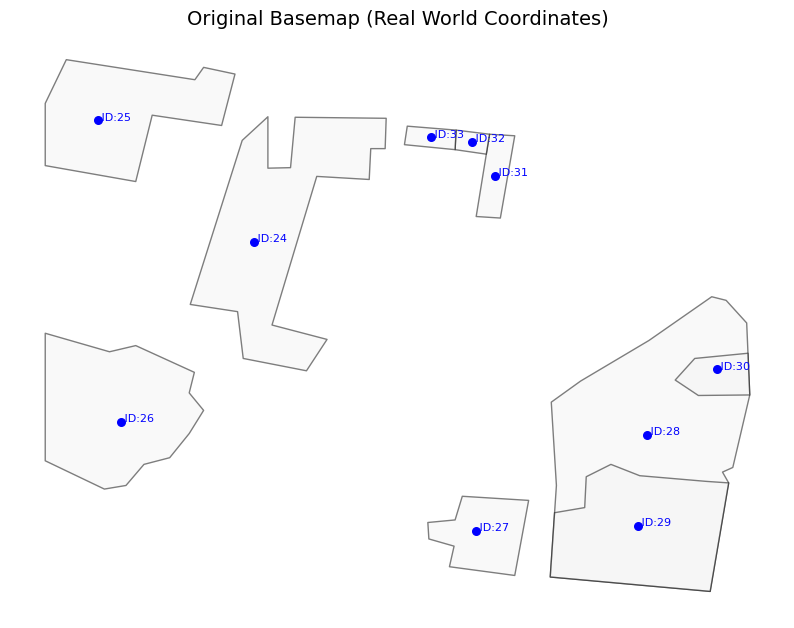

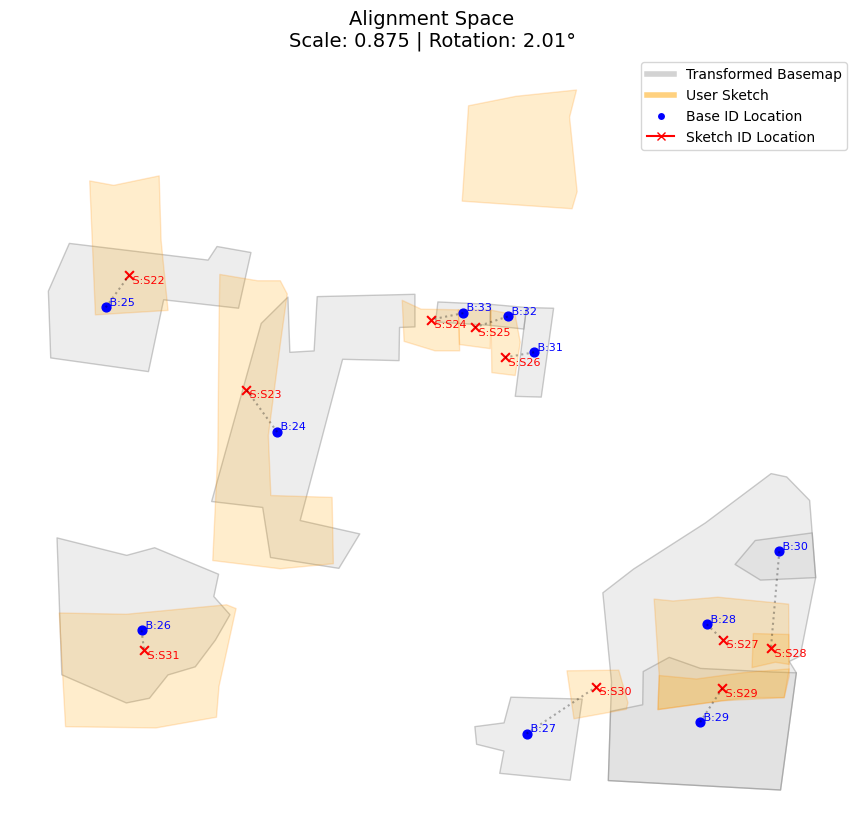

In [9]:
import matplotlib.pyplot as plt
from skimage import transform
from shapely.affinity import affine_transform
import numpy as np
from matplotlib.lines import Line2D

# --- 1. DATA PROCESSING & SYNCHRONIZATION ---
base_pts = []
sketch_pts = []
pair_labels = [] 

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    b_feats = bsm_landmarks[bsm_landmarks['id'].isin(b_indices)]
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_sid]
    
    if not s_feat.empty and not b_feats.empty:
        b_point = b_feats.geometry.representative_point()
        base_pts.append([b_point.x.mean(), b_point.y.mean()])
        
        s_point = s_feat.geometry.representative_point().values[0]
        sketch_pts.append([s_point.x, s_point.y])
        pair_labels.append((s_sid, b_indices[0])) 

X = np.array(base_pts)
Y = np.array(sketch_pts)

# --- 2. BIDIMENSIONAL REGRESSION ---
tform = transform.SimilarityTransform()
tform.estimate(X, Y)
predicted_Y = tform(X)

# --- 3. GEOMETRY TRANSFORMATION ---
m = tform.params
matrix = [m[0,0], m[0,1], m[1,0], m[1,1], m[0,2], m[1,2]]
bsm_transformed = bsm_landmarks.copy()
bsm_transformed['geometry'] = bsm_transformed['geometry'].apply(lambda x: affine_transform(x, matrix))

# Clean CRS
bsm_landmarks.crs = None
bsm_transformed.crs = None
skm_landmarks.crs = None

# --- 4. PLOT 1: ORIGINAL BASEMAP ---
fig1, ax1 = plt.subplots(figsize=(10, 8))
bsm_landmarks.plot(ax=ax1, color='whitesmoke', edgecolor='black', alpha=0.5)

# Plot the original base anchor points and their IDs
for i in range(len(X)):
    _, b_id = pair_labels[i]
    ax1.scatter(X[i, 0], X[i, 1], color='blue', s=30)
    ax1.text(X[i, 0], X[i, 1], f" ID:{b_id}", color='blue', fontsize=8)

ax1.set_title("Original Basemap (Real World Coordinates)", fontsize=14)
ax1.set_axis_off()

# --- 5. PLOT 2: ALIGNMENT (SKETCH + TRANSFORMED BASEMAP) ---
fig2, ax2 = plt.subplots(figsize=(12, 10))
ax2.set_aspect('equal')

# Plot Polygons
bsm_transformed.plot(ax=ax2, color='lightgray', edgecolor='gray', alpha=0.4)
skm_landmarks.plot(ax=ax2, color='orange', edgecolor='darkorange', alpha=0.2)

# Plot ID Labels and Error Connectors
for i in range(len(Y)):
    s_id, b_id = pair_labels[i]
    
    # Blue: Transformed Truth | Red: User Sketch
    ax2.scatter(predicted_Y[i, 0], predicted_Y[i, 1], color='blue', s=40, marker='o')
    ax2.scatter(Y[i, 0], Y[i, 1], color='red', s=40, marker='x')
    
    ax2.text(predicted_Y[i, 0], predicted_Y[i, 1], f" B:{b_id}", color='blue', fontsize=8, va='bottom')
    ax2.text(Y[i, 0], Y[i, 1], f" S:{s_id}", color='red', fontsize=8, va='top')
    
    # Connector
    ax2.plot([predicted_Y[i, 0], Y[i, 0]], [predicted_Y[i, 1], Y[i, 1]], color='black', linestyle=':', alpha=0.3)

plt.title(f"Alignment Space\nScale: {tform.scale:.3f} | Rotation: {np.degrees(tform.rotation):.2f}°", fontsize=14)

# Legend
legend_elements = [
    Line2D([0], [0], color='lightgray', lw=4, label='Transformed Basemap'),
    Line2D([0], [0], color='orange', lw=4, alpha=0.5, label='User Sketch'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Base ID Location'),
    Line2D([0], [0], marker='x', color='red', label='Sketch ID Location')
]
ax2.legend(handles=legend_elements, loc='upper right')
ax2.set_axis_off()

plt.show()

In [10]:
print(predicted_Y)

[[ 52.40529418 370.94139498]
 [188.12214348 272.22717864]
 [335.50960321 366.36551031]
 [370.69887399 363.72747514]
 [391.52784253 335.36280937]
 [528.09397878 120.07922856]
 [585.58635892 177.87920562]
 [522.88195487  42.5892063 ]
 [385.50383992  33.48134532]
 [ 80.72515443 115.32888876]]


## Using Centroid to Calculate the BDR

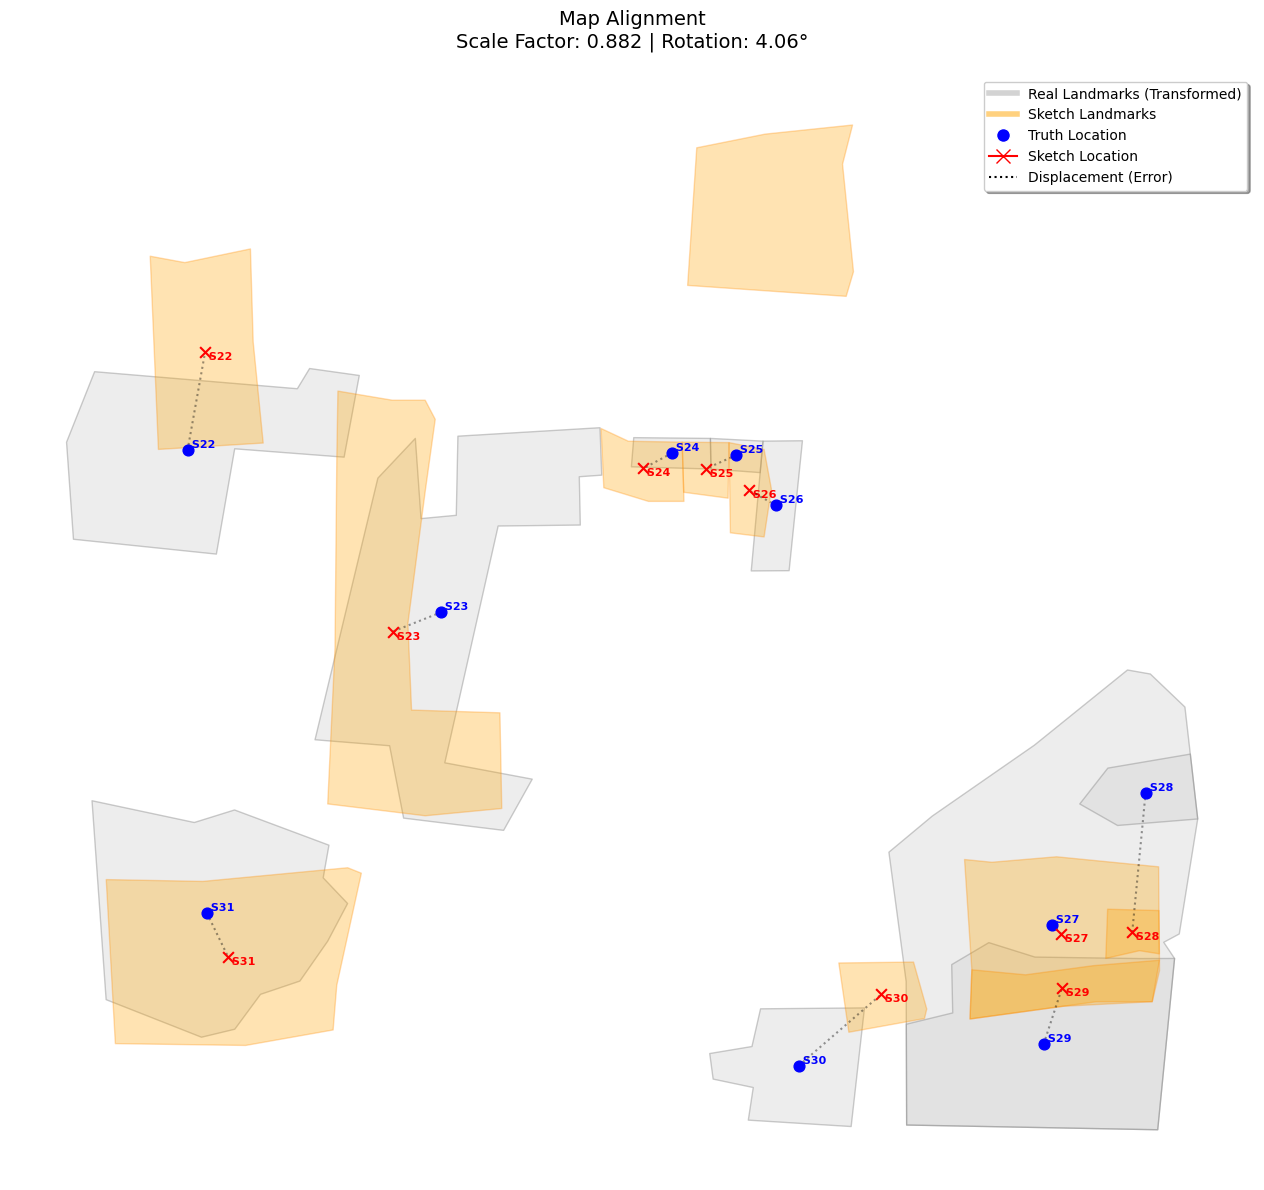

In [11]:
import matplotlib.pyplot as plt
from skimage import transform
from shapely.affinity import affine_transform
import numpy as np

# --- 1. DATA PROCESSING & SYNCHRONIZATION ---
base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    b_feats = bsm_landmarks[bsm_landmarks['id'].isin(b_indices)]
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_sid]
    
    if not s_feat.empty and not b_feats.empty:
        # Use representative_point to ensure dots stay inside building footprints
        b_point = b_feats.geometry.centroid
        base_pts.append([b_point.x.mean(), b_point.y.mean()])
        
        s_point = s_feat.geometry.centroid.values[0]
        sketch_pts.append([s_point.x, s_point.y])
        pair_labels.append(s_sid) 

X = np.array(base_pts)
Y = np.array(sketch_pts)

# --- 2. BIDIMENSIONAL REGRESSION ---
tform = transform.SimilarityTransform()
tform.estimate(X, Y)
predicted_Y = tform(X)

# --- 3. GEOMETRY TRANSFORMATION ---
# Move the Real Landmarks into Sketch Space so they overlap for the plot
m = tform.params
matrix = [m[0,0], m[0,1], m[1,0], m[1,1], m[0,2], m[1,2]]
bsm_transformed = bsm_landmarks.copy()
bsm_transformed['geometry'] = bsm_transformed['geometry'].apply(lambda x: affine_transform(x, matrix))

# IMPORTANT: Strip CRS to prevent "aspect must be finite" error
bsm_transformed.crs = None
skm_landmarks.crs = None

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_aspect('equal')

# Plot Polygons
bsm_transformed.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.4, label='Real World (Projected)')
skm_landmarks.plot(ax=ax, color='orange', edgecolor='darkorange', alpha=0.3, label='User Sketch')

# Plot Dots
# We plot the first one with a label for the legend, then loop the rest
ax.scatter(predicted_Y[:, 0], predicted_Y[:, 1], color='blue', s=60, marker='o', 
           label='Truth Anchor (Blue)', zorder=5)
ax.scatter(Y[:, 0], Y[:, 1], color='red', s=60, marker='x', 
           label='Sketch Anchor (Red)', zorder=5)

# Plot Labels and Connectors
for i in range(len(Y)):
    label = pair_labels[i]
    
    # Label the Blue Dot
    ax.text(predicted_Y[i, 0], predicted_Y[i, 1], f" {label}", 
            color='blue', fontsize=8, fontweight='bold', va='bottom')
    
    # Label the Red Dot
    ax.text(Y[i, 0], Y[i, 1], f" {label}", 
            color='red', fontsize=8, fontweight='bold', va='top')
    
    # Connector line (Error Vector)
    line, = ax.plot([predicted_Y[i, 0], Y[i, 0]], [predicted_Y[i, 1], Y[i, 1]], 
                    color='black', linestyle=':', alpha=0.4, zorder=4)

# Formatting
plt.title(f"Map Alignment\nScale Factor: {tform.scale:.3f} | Rotation: {np.degrees(tform.rotation):.2f}°", 
          fontsize=14, pad=20)

# Manually handle legend because geopandas.plot and ax.scatter work differently
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='lightgray', lw=4, label='Real Landmarks (Transformed)'),
    Line2D([0], [0], color='orange', lw=4, alpha=0.5, label='Sketch Landmarks'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Truth Location'),
    Line2D([0], [0], marker='x', color='red', markersize=10, label='Sketch Location'),
    Line2D([0], [0], color='black', linestyle=':', label='Displacement (Error)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, shadow=True)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [12]:
print(predicted_Y)

[[ 60.18819459 364.48290553]
 [199.49927079 275.72961614]
 [325.94480734 363.00578897]
 [361.25224289 361.88134909]
 [383.3190539  334.28498736]
 [534.39738703 104.19690968]
 [585.82395117 176.71659798]
 [529.87206358  38.72237661]
 [395.5289252   26.96816372]
 [ 70.86419751 110.5644909 ]]


## DI (Distortion Index)

In [13]:
import sklearn.metrics
r2 = sklearn.metrics.r2_score(Y, predicted_Y)
distortion_index = 100 * np.sqrt(1 - r2)
print((f"R²: {r2:.4f}"))
print((f"Distortion Index: {distortion_index:.2f}"))

R²: 0.9611
Distortion Index: 19.71


## Translation

In [14]:
alpha1 = tform.translation[0]
alpha2 = tform.translation[1]
print(f"Alpha 1 (X-Shift): {alpha1:.2f}")
print(f"Alpha 2 (Y-Shift): {alpha2:.2f}")

Alpha 1 (X-Shift): 27.50
Alpha 2 (Y-Shift): -105.22


## Correlation Coefficient (r)

In [15]:
from sklearn.metrics import r2_score
r2 = r2_score(Y, predicted_Y)
r = np.sqrt(r2)
print(f"Bidimensional Correlation (r): {r:.4f}")

Bidimensional Correlation (r): 0.9804


## Rotation 

In [16]:
# Convert radians to degrees
rotation_deg = np.degrees(tform.rotation)
print(f"Rotation (Theta): {rotation_deg:.2f}°")

Rotation (Theta): 4.06°


In [17]:
import pandas as pd
bdr_self = pd.DataFrame({
    'Alpha 1 (X)': alpha1,
    'Alpha 2 (Y)': alpha2,
    'Scale': tform.scale,
    'Rotation (Degrees)': rotation_deg,
    'R²': r2,
    'Distortion Index': distortion_index,
    'Correlation (r)': r,
}, index=[0]) 

bdr_GMDA = pd.DataFrame({
    'Alpha 1 (X)': -333.209,
    'Alpha 2 (Y)': -320.117,
    'Scale': 0.722,
    'Rotation (Degrees)': 1.944,
    'R²': 0.0,
    'Distortion Index': 18.218,
    'Correlation (r)': 0.983,
}, index=[0])

# 1. Combine the dataframes (make sure they have an index as discussed before)
# We transpose them (.T) so metrics are vertical for easier comparison
comparison = pd.concat([bdr_self.T, bdr_GMDA.T], axis=1)

# 2. Rename columns for clarity
comparison.columns = ['Your Calculation', 'GMDA Software']

# 3. Add a Difference column to check for precision
comparison['Difference'] = comparison['Your Calculation'] - comparison['GMDA Software']

# Display the comparison
print(comparison)

                    Your Calculation  GMDA Software  Difference
Alpha 1 (X)                27.500086       -333.209  360.709086
Alpha 2 (Y)              -105.220186       -320.117  214.896814
Scale                       0.882302          0.722    0.160302
Rotation (Degrees)          4.060852          1.944    2.116852
R²                          0.961143          0.000    0.961143
Distortion Index           19.712191         18.218    1.494191
Correlation (r)             0.980379          0.983   -0.002621


# GARDONY BASED - MEASURES

## Canonical Measures


### Canonical Score

In [18]:
import pandas as pd
import itertools


def calc_bas_can_score(X, Y, total_landmarks):
    """ 
    Calculates the Canonical Score (N/S and E/W relation)
    Parameters: 
    - X: np.array of Ground Truth coordinates (Base)
    - Y: np.array of Sketch coordinates
    - total_landmarks: int, total number of landmarks

    Returns: 
    - score: float( 0 to 100)
    """

    #Number of Landmarks in the Target Environment (Sketchmap)

    nTL = len(X)

    #Each landmark pair has 2 dimnesions (N/S and E/W)
    #Total comparisons = n * (n - 1) / 2   

    total_pairs_in_study = (total_landmarks * (total_landmarks - 1)) // 2

    max_possible_points = total_pairs_in_study * 2

    points_earned = 0

    if nTL < 2:
        return 0.0
    
    for i, j in itertools.combinations(range(nTL), 2):
        # 1. Calculate relative vectors for BaseMap (Truth)
        base_dx = X[j, 0] - X[i, 0] 
        base_dy = X[j, 1] - X[i, 1] 


        # 2. Calculate relative vectors for SketchMap 
        sketch_dx = Y[j, 0] - Y[i, 0] 
        sketch_dy = Y[j, 1] - Y[i, 1] 


        # Step 1 & 2: Check the N/S dimension 
        # use np.sign to see if the vertical direction is the same
        # (-1 for South, +1 for North, 0 for perfectly aligned)
        if np.sign(base_dy) == np.sign(sketch_dy):
            points_earned += 1

        #Step 4: E/W dimension check 
        # (-1 for West, +1 for East, 0 for perfectly aligned)
        if np.sign(base_dx) == np.sign(sketch_dx):
            points_earned += 1

    # Step 3: Logic is handled here: point_earned is only tallied here or summed up

    score = points_earned

    return score

In [19]:
import pandas as pd
import numpy as np
import itertools
import math

def calc_adv_canonical_score(base_csv, sketch_csv):
    # 1. Load Data
    base_df = pd.read_csv(base_csv)
    sketch_df = pd.read_csv(sketch_csv)

    # 2. Alignment
    # Ensure we only compare points that exist in both files 
    # based on Landmark ID and Rectangle Vertex ID
    merged = pd.merge(
        base_df, sketch_df, 
        on=['landmarkName', 'rectangleVertexNum'], 
        suffixes=('_base', '_sketch')
    )

    # Convert to arrays for speed
    base_coords = merged[['X_base', 'Y_base']].values
    sketch_coords = merged[['X_sketch', 'Y_sketch']].values
    landmark_ids = merged['landmarkName'].values
    
    n_total_points = len(merged)
    nTL = merged['landmarkName'].nunique() # Number of unique landmarks

    points_earned = 0
    comparisons_count = 0

    # 3. Vertex-to-Vertex Comparison Loop
    # Compare every point i with every point j
    for i, j in itertools.combinations(range(n_total_points), 2):
        
        # SKIP if the points belong to the same landmark
        if landmark_ids[i] == landmark_ids[j]:
            continue
            
        comparisons_count += 1
        
        # Calculate relative direction in Basemap
        base_dx = base_coords[j, 0] - base_coords[i, 0]
        base_dy = base_coords[j, 1] - base_coords[i, 1]
        
        # Calculate relative direction in Sketchmap
        sketch_dx = sketch_coords[j, 0] - sketch_coords[i, 0]
        sketch_dy = sketch_coords[j, 1] - sketch_coords[i, 1]
        
        # Check N/S
        if np.sign(base_dy) == np.sign(sketch_dy):
            points_earned += 1
            
        # Check E/W
        if np.sign(base_dx) == np.sign(sketch_dx):
            points_earned += 1

    # 4. Final Organization Score
    # The max possible points is comparisons_count * 2 (one for X, one for Y)
    if comparisons_count == 0:
        return 0.0
        
    can_score = points_earned
    
    return can_score, comparisons_count

# Example call:
# score = calc_advanced_canonical_score('basemap.csv', 'sketchmap.csv')
# print(f"Advanced Canonical Organization: {score:.4f}")

In [20]:
base_csv = r"datasets\rectangle_coords\rect_coords_basemap.csv"
sketch_csv = r"datasets\rectangle_coords\rect_coords_skm1.csv"
score, comps = calc_adv_canonical_score(base_csv, sketch_csv)
print(score, comps)

5460 2880


### Canonical Organization (CanOrg)

In [21]:
import math
def calc_can_org(can_score, nTL, method):
    """ 
    CanOrg = CanScore / 2*total_landmarks 
    """

    if method == "basic":
        basic_n = math.comb(nTL, 2) #here nTL = total landmarks in Target Environment (Basemap)

        can_org = can_score / (2 * basic_n)
        return can_org
    
    elif method == "advanced":
        advanced_n = math.comb(8 * nTL, 2) - (nTL * math.comb(8,2)) 

        can_org = can_score / (2 * advanced_n)

        return can_org 
    
    else:
        return "Invalid method specified. Choose 'basic' or 'advanced'." 
        


In [22]:
calc_can_org(can_score= score, nTL = len(X), method = "advanced")

0.9479166666666666

### Canonical Accuracy


In [23]:
def calc_can_acc(can_score, nDL, method):
    """ 
    CanAcc = CanScore / 2*total_landmarks 
    """

    if method == "basic":
        basic_n = math.comb(nDL, 2) #here nDL = total landmarks in Design Environment (Sketch)

        can_acc = can_score / (2 * basic_n)
        return can_acc
    
    elif method == "advanced":
        advanced_n = math.comb(8 * nDL, 2) - (nDL * math.comb(8,2)) 

        can_acc = can_score / (2 * advanced_n)

        return can_acc 
    
    else:
        return "Invalid method specified. Choose 'basic' or 'advanced'."

In [24]:
calc_can_acc(can_score= calc_bas_can_score(X, Y, total_landmarks = len(X)), nDL = len(X), method = "basic")

0.9555555555555556

# Rotational Bias

In [140]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

def get_centroids(df):
    return df.groupby('landmarkName').agg({'X': 'mean', 'Y': 'mean'}).to_dict('index')

def calc_rotational_bias(sketch_df, base_df, mode):
    sum_sin, sum_cos = 0.0, 0.0
    num_comps = 0
    
    if mode == "basic":
        sm_pts = get_centroids(sketch_df)
        bm_pts = get_centroids(base_df)
        landmarks = sorted(list(sm_pts.keys())) # Sort to ensure consistent pairing
        
        for i in range(len(landmarks)):
            for j in range(i + 1, len(landmarks)):
                l1, l2 = landmarks[i], landmarks[j]
                
                # Gardony standard: atan2(delta_x, delta_y)
                ang_bm = np.arctan2(bm_pts[l2]['X'] - bm_pts[l1]['X'], 
                                   bm_pts[l2]['Y'] - bm_pts[l1]['Y'])
                ang_sm = np.arctan2(sm_pts[l2]['X'] - sm_pts[l1]['X'], 
                                   sm_pts[l2]['Y'] - sm_pts[l1]['Y'])
                
                # Difference in orientation for this specific pair
                diff = ang_sm - ang_bm
                
                sum_sin += np.sin(diff)
                sum_cos += np.cos(diff)
                num_comps += 1

    elif mode == "advanced":
        landmarks = sorted(sketch_df['landmarkName'].unique())
        
        for i in range(len(landmarks)):
            for j in range(i + 1, len(landmarks)):
                l1_name, l2_name = landmarks[i], landmarks[j]
                
                l1_sm = sketch_df[sketch_df['landmarkName'] == l1_name].set_index('rectangleVertexNum')
                l2_sm = sketch_df[sketch_df['landmarkName'] == l2_name].set_index('rectangleVertexNum')
                l1_bm = base_df[base_df['landmarkName'] == l1_name].set_index('rectangleVertexNum')
                l2_bm = base_df[base_df['landmarkName'] == l2_name].set_index('rectangleVertexNum')

                for v1 in l1_sm.index:
                    for v2 in l2_sm.index:
                        ang_bm = np.arctan2(l2_bm.loc[v2, 'X'] - l1_bm.loc[v1, 'X'], 
                                           l2_bm.loc[v2, 'Y'] - l1_bm.loc[v1, 'Y'])
                        ang_sm = np.arctan2(l2_sm.loc[v2, 'X'] - l1_sm.loc[v1, 'X'], 
                                           l2_sm.loc[v2, 'Y'] - l1_sm.loc[v1, 'Y'])
                        
                        diff = ang_sm - ang_bm
                        sum_sin += np.sin(diff)
                        sum_cos += np.cos(diff)
                        num_comps += 1

    if num_comps == 0: return 0.0

    # Calculate average components
    avg_sin = sum_sin / num_comps
    avg_cos = sum_cos / num_comps
    
    # Final Bias
    rot_bias = np.degrees(np.arctan2(avg_sin, avg_cos))
    return rot_bias
# --- Usage ---
sketch_df = pd.read_csv(r'datasets\rectangle_coords\rect_coords_skm1.csv')
base_df = pd.read_csv(r'datasets\rectangle_coords\rect_coords_basemap.csv')

basic_bias = calc_rotational_bias(sketch_df, base_df, "basic")
adv_bias = calc_rotational_bias(sketch_df, base_df, "advanced")

print(f"Rotational Bias (Basic): {basic_bias:.2f}°")
print(f"Rotational Bias (Advanced): {adv_bias:.2f}°")

Rotational Bias (Basic): -2.39°
Rotational Bias (Advanced): -3.61°


rot bias basic = -0.18 
rot bias advanced = -3.28

software results 
rot  bias basic = -1.12
rot bias advanced = -3.61

In [42]:
print(Y)

[[ 69.81439424 418.24099079]
 [172.74045636 265.0579359 ]
 [310.25038228 354.54506631]
 [344.73043141 354.49132716]
 [368.06523955 342.57925216]
 [539.45812856  99.354174  ]
 [578.4935796  100.27037703]
 [539.8931124   69.35427463]
 [440.76222831  66.05449678]
 [ 82.4821413   86.60529121]]


# Angular Accuracy

To calculate the Angular Accuracy, we need to caclulate three things

1. angSM (angle of sketchmap pair) = atan2(L2_sm_x - L1_sm_x, L2_sm_y - L1_sm_y)
2. angBM (angle of basemap pair) = atan2(L2_bm_x - L1_bm_x, L2_bm_y - L1_bm_y)
3. angDIFF (difference between angles) = angSM - angBM

All of the above metrics are measured in radians.


In [117]:
import pandas as pd
import numpy as np
import math

def calculate_centroid(group):
    """Calculates the center point of a set of vertices."""
    return pd.Series({
        'X': group['X'].mean(),
        'Y': group['Y'].mean()
    })

def get_bearing(p1, p2):
    """Calculates bearing in radians between two points (X1, Y1) and (X2, Y2)."""
    return math.atan2(p2['X'] - p1['X'], p2['Y'] - p1['Y'])

def calc_an_acc(sketch_df, base_df, mode):
    running_angle_diff = 0.0
    num_comps = 0

    if mode == "basic":
        # Reduce each landmark to a single point (centroid)
        sm_points = sketch_df.groupby('landmarkName').apply(calculate_centroid, include_groups=False)
        bm_points = base_df.groupby('landmarkName').apply(calculate_centroid, include_groups=False)
        
        landmarks = sm_points.index.tolist()
        
        for i in range(len(landmarks)):
            for j in range(i + 1, len(landmarks)):
                l1, l2 = landmarks[i], landmarks[j]
                
                ang_sm = get_bearing(sm_points.loc[l1], sm_points.loc[l2])
                ang_bm = get_bearing(bm_points.loc[l1], bm_points.loc[l2])
                
                diff_rad = (ang_sm - ang_bm + math.pi) % (2 * math.pi) - math.pi
                running_angle_diff += abs(math.degrees(diff_rad))
                num_comps += 1

    elif mode == "advanced":
        # Compare every vertex of Landmark A to every vertex of Landmark B
        landmarks = sketch_df['landmarkName'].unique()
        
        for i in range(len(landmarks)):
            for j in range(i + 1, len(landmarks)):
                l1_name, l2_name = landmarks[i], landmarks[j]
                
                # Get all vertices for these two landmarks
                l1_sm = sketch_df[sketch_df['landmarkName'] == l1_name]
                l2_sm = sketch_df[sketch_df['landmarkName'] == l2_name]
                l1_bm = base_df[base_df['landmarkName'] == l1_name]
                l2_bm = base_df[base_df['landmarkName'] == l2_name]

                # Nested loop through vertices (0-7 for each)
                for idx1 in l1_sm.index:
                    for idx2 in l2_sm.index:
                        # Ensure we are comparing the same rectangleVertexNum
                        p1_sm, p2_sm = l1_sm.loc[idx1], l2_sm.loc[idx2]
                        p1_bm, p2_bm = l1_bm.loc[idx1], l2_bm.loc[idx2]

                        ang_sm = get_bearing(p1_sm, p2_sm)
                        ang_bm = get_bearing(p1_bm, p2_bm)

                        diff_rad = (ang_sm - ang_bm + math.pi) % (2 * math.pi) - math.pi
                        running_angle_diff += abs(math.degrees(diff_rad))
                        num_comps += 1

    if num_comps == 0:
        return 0

    # Final Accuracy: 1 - (Mean Absolute Error / Max Possible Error)
    mean_error = running_angle_diff / num_comps
    return 1.0 - (mean_error / 180.0)

# --- Execution ---
# Load your data
sketch_df = pd.read_csv(r'datasets\rectangle_coords\rect_coords_skm1.csv')
base_df = pd.read_csv(r'datasets\rectangle_coords\rect_coords_basemap.csv')

basic_acc = calc_an_acc(sketch_df, base_df, "basic")
adv_acc = calc_an_acc(sketch_df, base_df, "advanced")

print(f"Basic Mode Accuracy (Centroids): {basic_acc:.4f}")
print(f"Advanced Mode Accuracy (All Vertices): {adv_acc:.4f}")

Basic Mode Accuracy (Centroids): 0.9408
Advanced Mode Accuracy (All Vertices): 0.9349


basic mode = 0.95 
advanced mode = 0.93

# Building Pipeline for BDR and  GMDA- based measures

1. Extract Polygons from GeoJSON files
2. Draw minimum bounding box
3. Extract 8 points for each landmark/polygon
4. Calculate the BDR and GMDA-based measures


## 1. Extract Polygons from GeoJSON files 


Skipping field BaseAlign: unsupported OGR type: 1
Skipping field SketchAlign: unsupported OGR type: 5


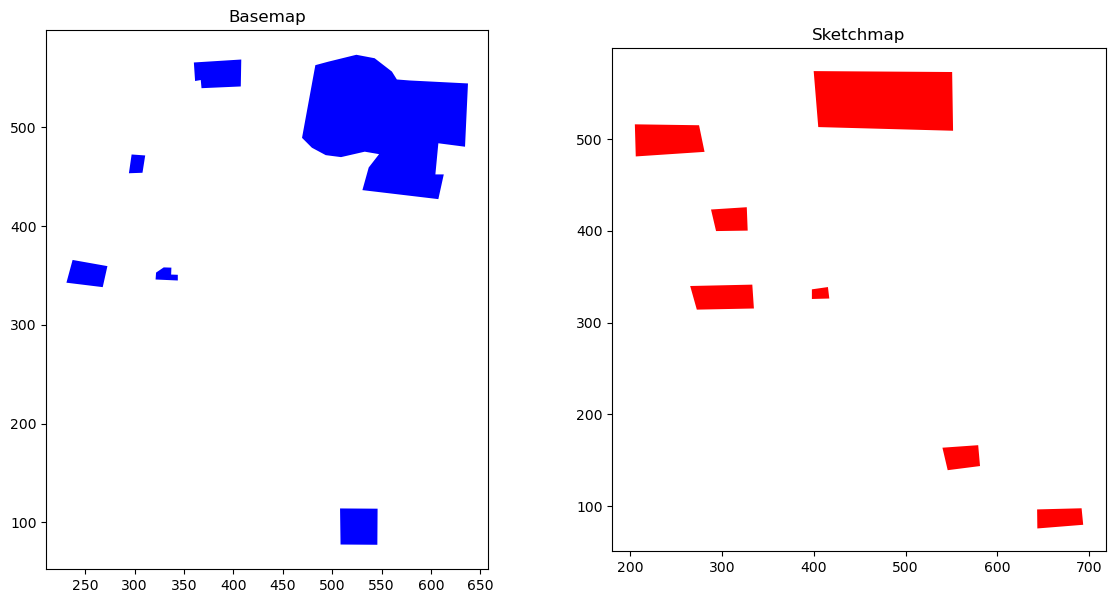

In [65]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Extract landmarks from the basemap
bsm_feat = gpd.read_file(r"C:\Users\ajays\Downloads\Results (1)\GeneralizedBaseMap\AS_Sketch_1.jpg.geojson")
bsm_landmarks = bsm_feat[(bsm_feat['feat_type'] == 'Landmark') & (bsm_feat['aligned'] == True)]

# Extract landmarks from the sketchmap
skm_feat = gpd.read_file(r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\AS_Sketch_1.jpg.geojson")
skm_landmarks = skm_feat[
    ((skm_feat['feat_type'] == 'Landmark') | (skm_feat['otype'] == 'CircleMarker') & (skm_feat['aligned'] == True))    
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

bsm_landmarks.plot(ax=axes[0], color='blue')
axes[0].set_title('Basemap')
axes[0].set_aspect('equal')

skm_landmarks.plot(ax=axes[1], color='red')
axes[1].set_title('Sketchmap')
axes[1].set_aspect('equal')

plt.show()

Skipping field BaseAlign: unsupported OGR type: 1


Skipping field SketchAlign: unsupported OGR type: 5
C:\Users\ajays\AppData\Local\Temp\ipykernel_9176\2759145296.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(len(sids_sorted), 1))


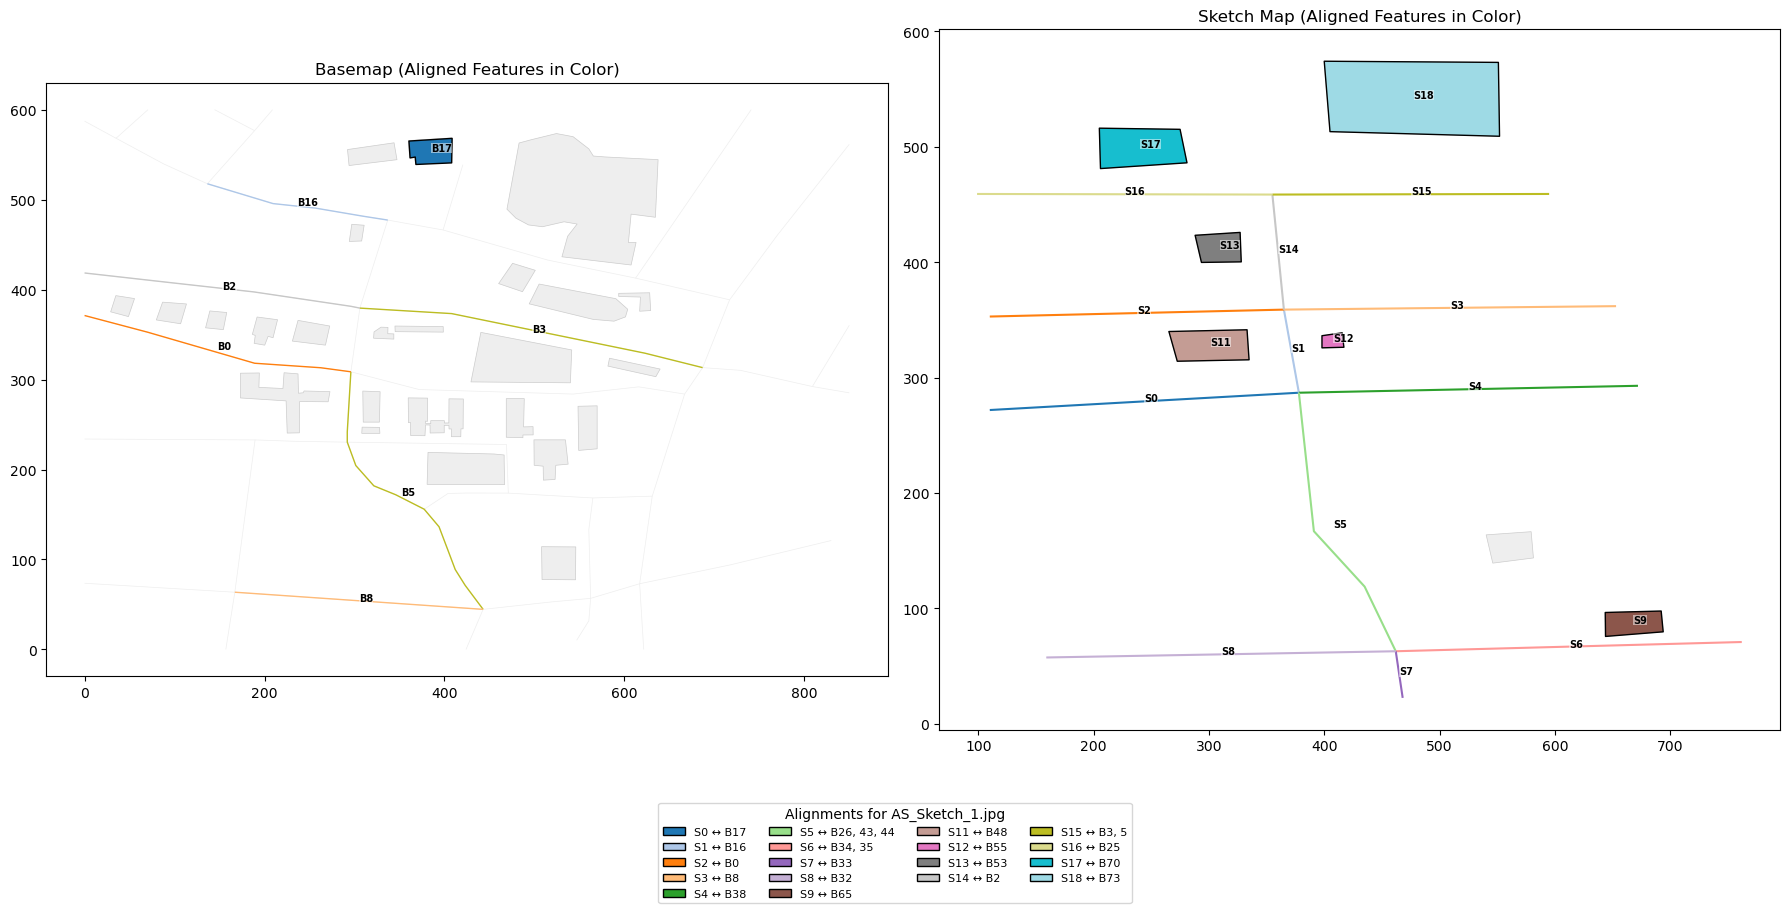

In [8]:
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch

# =============================================================================
# CONFIGURATION
# =============================================================================
BSM_PATH = r"C:\Users\ajays\Downloads\Results (1)\GeneralizedBaseMap\AS_Sketch_1.jpg.geojson"
SKM_PATH = r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\AS_Sketch_1.jpg.geojson"

SKETCH_NAME = "AS_Sketch_1.jpg" 
ALIGN_SOURCE = 'excel' 

ALIGN_PATHS = {
    'csv'   : r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\alignment.csv",
    'excel' : r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\alignment.xlsx",
    'json'  : r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\alignment.json",
}

# =============================================================================
# DATA LOADERS
# =============================================================================

def _standardize_ids(value):
    """Safely handles strings, lists, and dicts to extract numeric ID strings."""
    # Handle None or empty cases safely
    if value is None:
        return []
    
    # If it's a dict (e.g., {"0": [17]}), recurse into the values
    if isinstance(value, dict):
        out = []
        for v in value.values():
            out.extend(_standardize_ids(v))
        return out
        
    # If it's a list (e.g., [26, 43, 44]), recurse into each item
    if isinstance(value, (list, tuple)):
        out = []
        for item in value:
            out.extend(_standardize_ids(item))
        return out
    
    # Handle scalar values (strings/numbers)
    # Check for NaN only on scalars to avoid the ValueError
    if pd.isna(value):
        return []
    
    # Clean string: remove 'S' prefix, split by spaces or commas
    tokens = str(value).strip().replace(',', ' ').split()
    final_ids = []
    for tok in tokens:
        if tok.lower().startswith('s') and tok[1:].isdigit():
            tok = tok[1:]
        if tok:
            final_ids.append(tok)
    return final_ids

def load_alignment_from_json(path, target_sketch):
    """Accesses the specific sketch map and extracts alignment pairs."""
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    if target_sketch not in data:
        print(f"⚠️ Warning: {target_sketch} not found. Using empty alignment.")
        return {}

    sketch_data = data[target_sketch]
    pairs = {}
    
    for k, content in sketch_data.items():
        if not isinstance(content, dict): continue
        
        b_raw = content.get('BaseAlign')
        s_raw = content.get('SketchAlign')
        
        if b_raw is not None and s_raw is not None:
            b_ids = _standardize_ids(b_raw)
            s_ids = _standardize_ids(s_raw)
            for sid in s_ids:
                pairs.setdefault(sid, []).extend(b_ids)
    return pairs

# =============================================================================
# MAIN EXECUTION
# =============================================================================

path = ALIGN_PATHS[ALIGN_SOURCE]

if ALIGN_SOURCE == 'json':
    align_pairs = load_alignment_from_json(path, SKETCH_NAME)
else:
    df = pd.read_csv(path, dtype=str) if path.endswith('.csv') else pd.read_excel(path, dtype=str)
    # Flexible column detection for tables
    cols = {c.lower().replace(' ', ''): c for c in df.columns}
    b_col = cols.get('baseid', df.columns[0])
    s_col = cols.get('sketchid', df.columns[1])
    
    align_pairs = {}
    for _, row in df.iterrows():
        b_ids = _standardize_ids(row[b_col])
        s_ids = _standardize_ids(row[s_col])
        for sid in s_ids:
            align_pairs.setdefault(sid, []).extend(b_ids)

# Deduplicate Base IDs per Sketch ID
align_pairs = {sid: list(dict.fromkeys(bids)) for sid, bids in align_pairs.items()}

# Load Geometries
bsm_full = gpd.read_file(BSM_PATH)
skm_full = gpd.read_file(SKM_PATH)

# Match IDs (ensure strings for comparison)
bsm_land = bsm_full[bsm_full['id'].astype(str).isin({b for bl in align_pairs.values() for b in bl})].copy()
skm_land = skm_full[skm_full['id'].astype(str).isin(set(align_pairs.keys()))].copy()

# =============================================================================
# VISUALIZATION
# =============================================================================

if bsm_land.empty or skm_land.empty:
    print(f"❌ No spatial matches found. Check if GeoJSON 'id' values match alignment IDs.")
    print(f"Sample Alignment IDs: {list(align_pairs.keys())[:5]}")
    print(f"Sample GeoJSON IDs: {skm_full['id'].iloc[:5].tolist()}")
else:
    # Color mapping
    sids_sorted = sorted(align_pairs.keys(), key=lambda x: int(x) if x.isdigit() else 999)
    cmap = cm.get_cmap('tab20', max(len(sids_sorted), 1))
    color_map = {sid: cmap(i) for i, sid in enumerate(sids_sorted)}

    skm_land['color'] = skm_land['id'].astype(str).map(color_map)
    bid_to_color = {str(bid): color_map[sid] for sid, bids in align_pairs.items() for bid in bids}
    bsm_land['color'] = bsm_land['id'].astype(str).map(bid_to_color)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    
    # Plot backgrounds
    bsm_full.plot(ax=ax1, color='#eeeeee', edgecolor='#cccccc', linewidth=0.5)
    skm_full.plot(ax=ax2, color='#eeeeee', edgecolor='#cccccc', linewidth=0.5)

    # Plot aligned landmarks
    bsm_land.plot(ax=ax1, color=bsm_land['color'], edgecolor='black', linewidth=1, aspect='equal')
    skm_land.plot(ax=ax2, color=skm_land['color'], edgecolor='black', markersize=100, aspect='equal')

    # Add Centroid Labels
    for ax, gdf, pref in zip([ax1, ax2], [bsm_land, skm_land], ['B', 'S']):
        for _, row in gdf.iterrows():
            c = row.geometry.centroid
            ax.text(c.x, c.y, f"{pref}{row['id']}", fontsize=7, fontweight='bold', 
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0))

    ax1.set_title("Basemap (Aligned Features in Color)")
    ax2.set_title("Sketch Map (Aligned Features in Color)")
    
    # Informative Legend
    legend_elements = [Patch(facecolor=color_map[sid], edgecolor='black', 
                       label=f"S{sid} ↔ B{', '.join(align_pairs[sid])}") 
                       for sid in sids_sorted if sid in skm_land['id'].astype(str).values]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=8, 
               title=f"Alignments for {SKETCH_NAME}", frameon=True)

    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.show()

=== ALIGNMENT VALIDATION REPORT ===
Total Unique SIDs Found:             33
Perfectly Paired (colored on both):  33
SIDs only in Sketch (gray on Base):  set()
SIDs only in Basemap (gray on Sketch): set()


=== ALIGNMENT PAIRINGS (Group L  →  Basemap IDs  ↔  Sketchmap IDs) ===
L (SID)   Basemap IDs              Sketchmap IDs            
------------------------------------------------------------
S0        0                        0                        
S1        1                        1                        
S10       10                       10                       
S11       11                       11                       
S12       12                       12                       
S13       13                       13                       
S14       G12                      14                       
S15       G12                      15                       
S16       G12                      16                       
S17       17                       17               

C:\Users\ajays\AppData\Local\Temp\ipykernel_9176\3691551243.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(all_sids) if all_sids else 1)


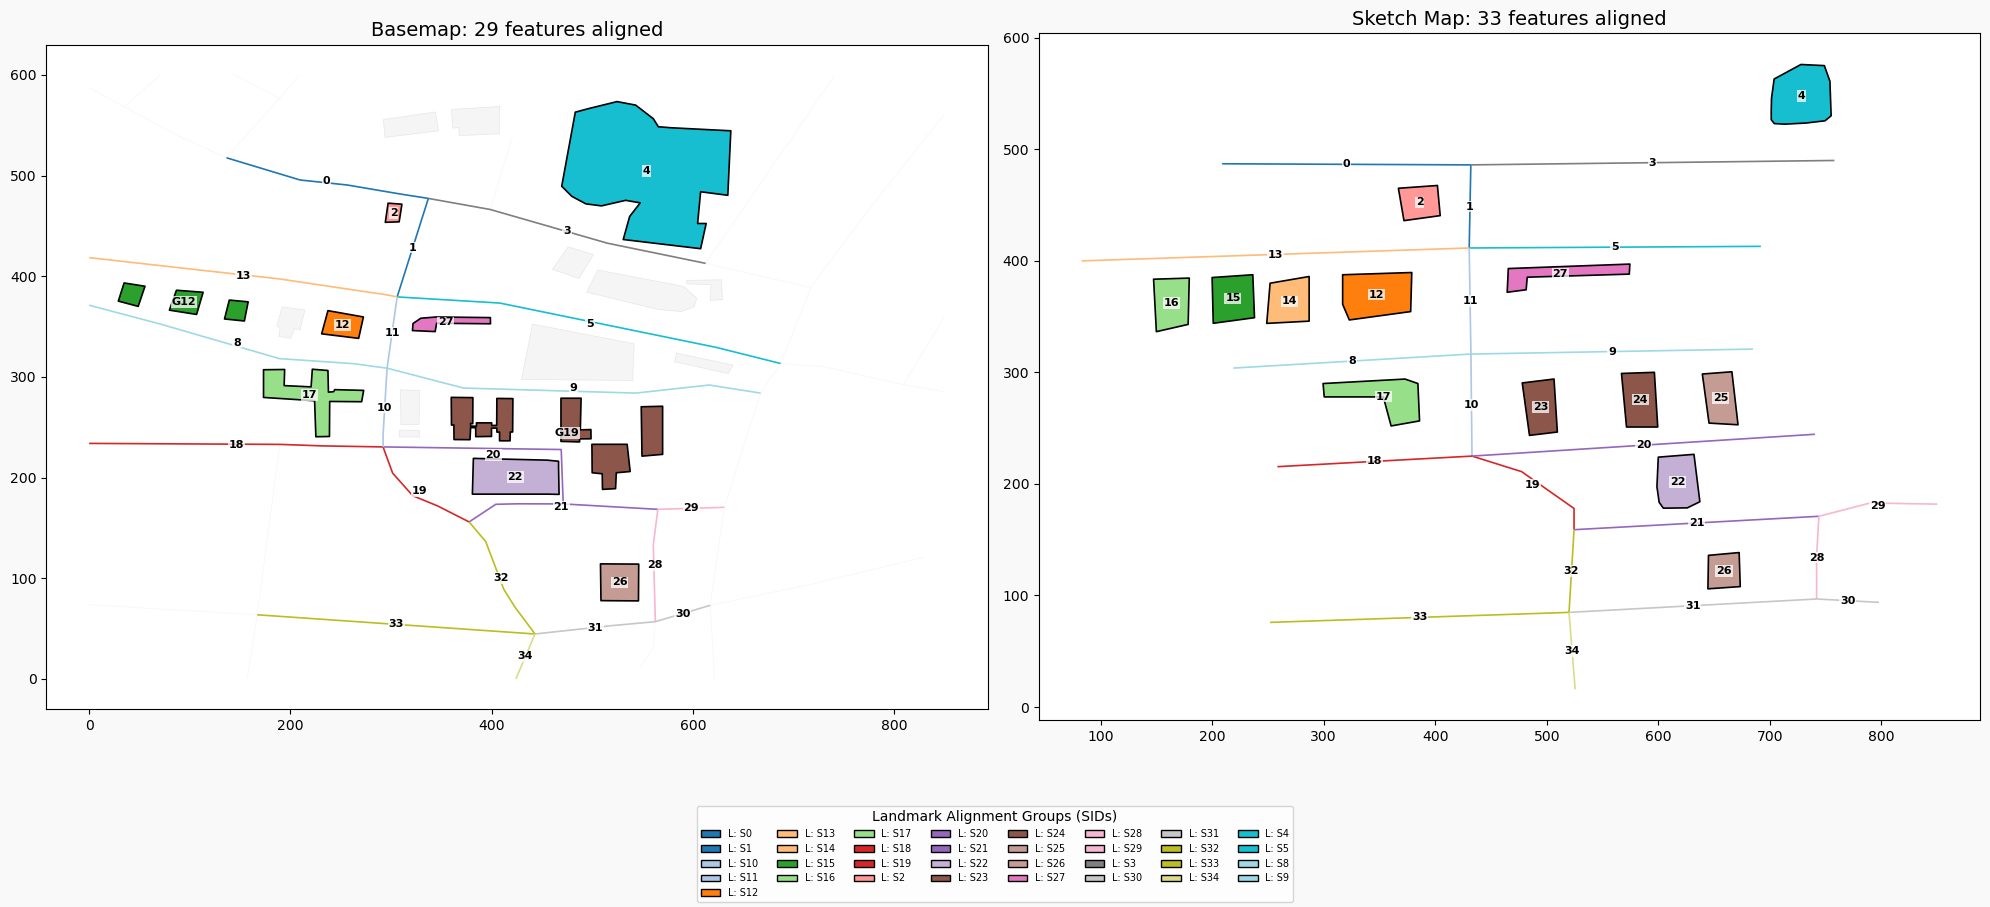

In [5]:
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from shapely.geometry import shape

# =============================================================================
# FILE PATHS
# =============================================================================
SKETCH_PATH  = r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\AS_Sketch_3.jpg.geojson"
BASEMAP_PATH = r"C:\Users\ajays\Downloads\Results (1)\GeneralizedBaseMap\AS_Sketch_3.jpg.geojson"


# =============================================================================
# DATA LOADING
# =============================================================================

def load_geojson_safely(path):
    """Loads a geojson while preserving nested fields (BaseAlign/SketchAlign)
       that geopandas would otherwise drop."""
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    features = []
    for feat in data['features']:
        properties = feat['properties'].copy()
        properties['geometry'] = shape(feat['geometry'])
        features.append(properties)
    return gpd.GeoDataFrame(features)

skm_full = load_geojson_safely(SKETCH_PATH)
bsm_full = load_geojson_safely(BASEMAP_PATH)


# =============================================================================
# ROBUST MANY-TO-MANY ALIGNMENT LOGIC
# =============================================================================

# 1. Collect every Aligned SID from BOTH files
skm_sids = set(skm_full[skm_full['aligned'] == True]['sid'].unique())

bsm_sids = set()
for val in bsm_full[bsm_full['aligned'] == True]['SketchAlign'].dropna():
    if isinstance(val, list):
        bsm_sids.update([str(v) for v in val])
    else:
        bsm_sids.add(str(val))

all_sids = sorted(list(skm_sids | bsm_sids))


# -----------------------------------------------------------------------------
# VALIDATION CHECK
# -----------------------------------------------------------------------------
perfect_matches = skm_sids.intersection(bsm_sids)
only_in_sketch  = skm_sids - bsm_sids
only_in_base    = bsm_sids - skm_sids

print("=== ALIGNMENT VALIDATION REPORT ===")
print(f"Total Unique SIDs Found:             {len(all_sids)}")
print(f"Perfectly Paired (colored on both):  {len(perfect_matches)}")
print(f"SIDs only in Sketch (gray on Base):  {only_in_sketch}")
print(f"SIDs only in Basemap (gray on Sketch): {only_in_base}")
print("===================================\n")

# Many-to-One detection
for sid in perfect_matches:
    count = len(bsm_full[bsm_full['SketchAlign'].apply(
        lambda x: sid in x if isinstance(x, list) else x == sid)])
    if count > 1:
        print(f"Landmark {sid} is 'Many': it consists of {count} polygons in the Basemap.")


# 2. Create a consistent color map (one color per SID)
cmap = cm.get_cmap('tab20', len(all_sids) if all_sids else 1)
sid_color_dict = {sid: cmap(i) for i, sid in enumerate(all_sids)}


# 3. Helper: pick the first SID from a basemap feature's SketchAlign field
def extract_bsm_sid(val):
    if isinstance(val, list) and len(val) > 0:
        return str(val[0])
    return str(val) if pd.notnull(val) else None


# 4. Apply colors
skm_full['group_color'] = skm_full.apply(
    lambda r: sid_color_dict.get(r['sid']) if r['aligned'] else None, axis=1)

bsm_full['group_color'] = bsm_full.apply(
    lambda r: sid_color_dict.get(extract_bsm_sid(r.get('SketchAlign'))) if r['aligned'] else None, axis=1)


# =============================================================================
# PAIRINGS TABLE (printed to console)
# =============================================================================
bsm_highlights = bsm_full[bsm_full['group_color'].notnull()].copy()
skm_highlights = skm_full[skm_full['group_color'].notnull()].copy()

print("\n=== ALIGNMENT PAIRINGS (Group L  →  Basemap IDs  ↔  Sketchmap IDs) ===")
print(f"{'L (SID)':<10}{'Basemap IDs':<25}{'Sketchmap IDs':<25}")
print("-" * 60)

for sid in all_sids:
    # Basemap features pointing to this SID
    bsm_ids = bsm_highlights[
        bsm_highlights['SketchAlign'].apply(
            lambda x: sid in [str(v) for v in x] if isinstance(x, list)
                      else str(x) == sid
        )
    ]['id'].astype(str).tolist()
    
    # Sketchmap features with this SID
    skm_ids = skm_highlights[skm_highlights['sid'].astype(str) == sid]['id'].astype(str).tolist()
    
    bsm_str = ', '.join(bsm_ids) if bsm_ids else '—'
    skm_str = ', '.join(skm_ids) if skm_ids else '—'
    print(f"{sid:<10}{bsm_str:<25}{skm_str:<25}")

print("-" * 60 + "\n")


# =============================================================================
# VISUALIZATION
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor('#f9f9f9')

# Plot Basemap (gray background + colored aligned features on top)
bsm_full.plot(ax=ax1, color='#e0e0e0', edgecolor='#bcbcbc', linewidth=0.5, alpha=0.3)
if not bsm_highlights.empty:
    bsm_highlights.plot(ax=ax1, color=bsm_highlights['group_color'],
                        edgecolor='black', linewidth=1.2)
ax1.set_title(f"Basemap: {len(bsm_highlights)} features aligned", fontsize=14)

# Plot Sketch Map (same idea)
skm_full.plot(ax=ax2, color='#e0e0e0', edgecolor='#bcbcbc', linewidth=0.5, alpha=0.3)
if not skm_highlights.empty:
    skm_highlights.plot(ax=ax2, color=skm_highlights['group_color'],
                        edgecolor='black', linewidth=1.2)
ax2.set_title(f"Sketch Map: {len(skm_highlights)} features aligned", fontsize=14)


# -----------------------------------------------------------------------------
# Labels — show each feature's original ID
#   Basemap → B<id>    Sketchmap → S<id>
# -----------------------------------------------------------------------------
for ax, gdf, is_bsm in zip([ax1, ax2], [bsm_highlights, skm_highlights], [True, False]):
    prefix = 'B' if is_bsm else 'S'
    for _, row in gdf.iterrows():
        c = row.geometry.centroid
        feat_id = row.get('id', '?')
        ax.text(c.x, c.y, str(feat_id),    # no prefix
        fontsize=8, fontweight='bold',
        ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.75,
                  edgecolor='none', pad=0.6))


# -----------------------------------------------------------------------------
# Legend
# -----------------------------------------------------------------------------
legend_elements = [
    Patch(facecolor=sid_color_dict[sid], edgecolor='black', label=f"L: {sid}")
    for sid in all_sids
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=min(len(all_sids), 8) if all_sids else 1,
           fontsize=7, title="Landmark Alignment Groups (SIDs)")

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

In [6]:
# =============================================================================
# FIND COMMON LANDMARK PAIRS (present in BOTH basemap and sketchmap)
# =============================================================================

def find_common_pairs(bsm_full, skm_full):
    """
    Returns a list of dicts, one per common landmark group:
        [
          {
            'sid'         : 'L group / sketch alignment id',
            'basemap_ids' : [list of basemap feature IDs in this group],
            'sketch_ids'  : [list of sketchmap feature IDs in this group],
            'is_many_to_one': True/False,
          },
          ...
        ]
    A pair is "common" if at least one basemap feature AND at least one
    sketchmap feature share the same SID.
    """
    # 1. Collect SIDs from the sketchmap (each aligned sketch feature has a 'sid')
    skm_aligned = skm_full[skm_full['aligned'] == True]
    skm_sids = set(skm_aligned['sid'].astype(str).unique())
    
    # 2. Collect SIDs from the basemap (in 'SketchAlign', possibly a list)
    bsm_aligned = bsm_full[bsm_full['aligned'] == True]
    bsm_sids = set()
    for val in bsm_aligned['SketchAlign'].dropna():
        if isinstance(val, list):
            bsm_sids.update(str(v) for v in val)
        else:
            bsm_sids.add(str(val))
    
    # 3. Common SIDs = present in BOTH
    common_sids = sorted(skm_sids & bsm_sids,
                         key=lambda x: int(x) if str(x).isdigit() else 9999)
    
    # 4. For each common SID, list the basemap & sketchmap feature IDs
    pairs = []
    for sid in common_sids:
        # Basemap features whose SketchAlign contains this SID
        bsm_match = bsm_aligned[bsm_aligned['SketchAlign'].apply(
            lambda x: sid in [str(v) for v in x] if isinstance(x, list)
                      else str(x) == sid
        )]
        bsm_ids = bsm_match['id'].astype(str).tolist()
        
        # Sketchmap features with this SID
        skm_match = skm_aligned[skm_aligned['sid'].astype(str) == sid]
        skm_ids = skm_match['id'].astype(str).tolist()
        
        pairs.append({
            'sid'           : sid,
            'basemap_ids'   : bsm_ids,
            'sketch_ids'    : skm_ids,
            'is_many_to_one': len(bsm_ids) > 1 or len(skm_ids) > 1,
        })
    
    return pairs


# --- Run it ---
common_pairs = find_common_pairs(bsm_full, skm_full)

# --- Print a clean summary ---
print("=" * 70)
print(f"COMMON LANDMARK PAIRS  ({len(common_pairs)} groups found)")
print("=" * 70)
print(f"{'SID':<8}{'Basemap IDs':<25}{'Sketchmap IDs':<25}{'Type':<10}")
print("-" * 70)

for p in common_pairs:
    pair_type = 'many'  if p['is_many_to_one'] else '1:1'
    print(f"{p['sid']:<8}"
          f"{', '.join(p['basemap_ids']):<25}"
          f"{', '.join(p['sketch_ids']):<25}"
          f"{pair_type:<10}")

print("-" * 70)
print(f"Total common groups : {len(common_pairs)}")
print(f"  1:1 pairs         : {sum(1 for p in common_pairs if not p['is_many_to_one'])}")
print(f"  many-to-many      : {sum(1 for p in common_pairs if p['is_many_to_one'])}")
print("=" * 70)

COMMON LANDMARK PAIRS  (33 groups found)
SID     Basemap IDs              Sketchmap IDs            Type      
----------------------------------------------------------------------
S23     G19                      23                       1:1       
S30     30                       30                       1:1       
S3      3                        3                        1:1       
S27     27                       27                       1:1       
S18     18                       18                       1:1       
S24     G19                      24                       1:1       
S5      5                        5                        1:1       
S25     G19                      25                       1:1       
S34     34                       34                       1:1       
S13     13                       13                       1:1       
S31     31                       31                       1:1       
S10     10                       10                       1:

## 2. Draw a Minimum Bounding box for each of the Landmarks

<Axes: >

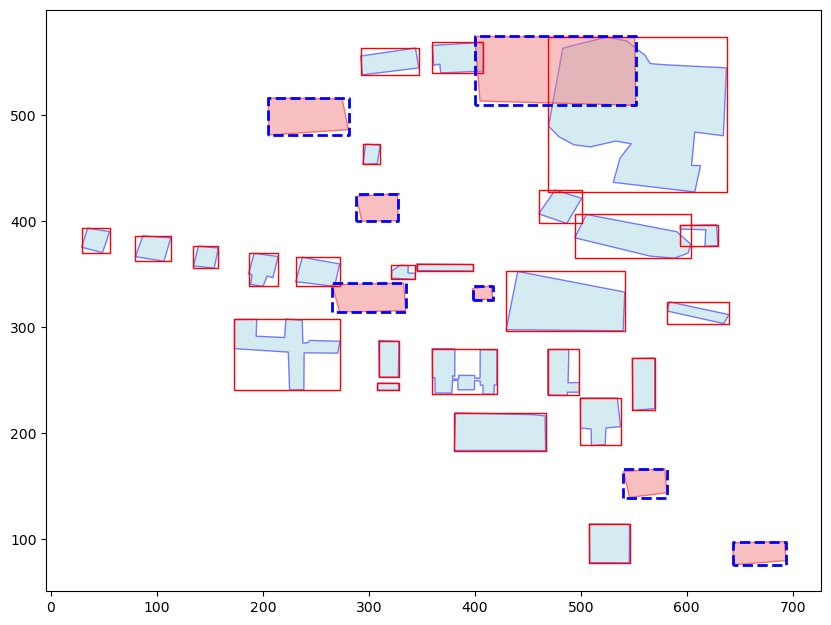

In [50]:
import geopandas as gpd

# 1. Load your data
bsm_gdf = gpd.GeoDataFrame.from_features(bsm_landmarks) # for basemap landmarks
skm_gdf = gpd.GeoDataFrame.from_features(skm_landmarks) # for sketchmap landmarks

buffer_size = 1
# 2. Explicitly create the bounding boxes as a GeoSeries
# This ensures GeoPandas knows these are geometries from the start
bsm_gdf['tight_bbox'] = bsm_gdf.geometry.apply(
    lambda g: g.buffer(buffer_size).envelope if g.geom_type == 'Point' else g.envelope
) # fpr basemap landmarks
skm_gdf['tight_bbox'] = skm_gdf.geometry.apply(
    lambda s: s.buffer(buffer_size).envelope if s.geom_type == 'Point' else s.envelope
) # for sketchmap landmarks


# 3. Plotting
# We use .geometry.boundary to get just the outlines of the original shapes
ax = bsm_gdf.geometry.plot(color='lightblue', edgecolor='blue', alpha=0.5, figsize=(10, 10))
ax = skm_gdf.geometry.plot(ax=ax, color='lightcoral', edgecolor='red', alpha=0.5)

# Now set_geometry should work because 'tight_bbox' is a proper GeoSeries
bsm_gdf.set_geometry('tight_bbox').boundary.plot(ax=ax, color='red', linewidth=1, label = 'BSM_BBOX')
skm_gdf.set_geometry('tight_bbox').boundary.plot(ax=ax, color='blue', linewidth=2, linestyle = '--', label = 'SKM BBOX')

In [4]:
minx, miny, maxx, maxy = skm_gdf.total_bounds
print(f"Map Width: {maxx - minx}")

Map Width: 577.854054


## 3. Extract 8-points each for every polygon

In [24]:
from shapely.geometry import Point 
import numpy as np


def extract_bbox(geometry):
    """ Extracts the bounding box of a geometry and returns it the vertices and midpoints """
    coords = list(geometry.exterior.coords)

    v = coords[:4]  # Assuming the first 4 points are the vertices

    midpoints = []

    for i in range(4):
        p1 = coords[i]
        p2 = coords[i + 1]

        mid = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)
        midpoints.append(mid)

    return v, midpoints


#applying the function to the 'tight_bbox' colums to extract vertices and midpoints 
results_bsm = bsm_gdf['tight_bbox'].apply(extract_bbox)
results_skm = skm_gdf['tight_bbox'].apply(extract_bbox)


#Storing the vertices and midpoints in separate columns for easier access
#For basemap
bsm_gdf['vertices'] = results_bsm.apply(lambda x : x[0])
bsm_gdf['midpoints'] = results_bsm.apply(lambda x : x[1])

#For sketchmap
skm_gdf['vertices'] = results_skm.apply(lambda x : x[0])
skm_gdf['midpoints'] = results_skm.apply(lambda x : x[1])

# print("Vertices of the first polygon:", bsm_gdf['vertices'].iloc[0])
# print("Midpoints of the first polygon:", bsm_gdf['midpoints'].iloc[0])

# print("Vertices of the first polygon in Sketchmap:", skm_gdf['vertices'].iloc[0])
# print("Midpoints of the first polygon in Sketchmap:", skm_gdf['midpoints'].iloc[0])

X = []
for _, row in bsm_gdf.sort_values('id').iterrows():
    X.extend(row['vertices'] + row['midpoints'])

Y = []
for _, row in skm_gdf.sort_values('id').iterrows():
    Y.extend(row['vertices'] + row['midpoints'])


ids = np.repeat(bsm_gdf.sort_values('id')['id'].values, 8)

print(X)


[(231.0, 338.245561), (272.5, 338.245561), (272.5, 365.771677), (231.0, 365.771677), (251.75, 338.245561), (272.5, 352.008619), (251.75, 365.771677), (231.0, 352.008619), (186.5, 338.245561), (214.5, 338.245561), (214.5, 369.525239), (186.5, 369.525239), (200.5, 338.245561), (214.5, 353.8854), (200.5, 369.525239), (186.5, 353.8854), (134.5, 355.511943), (158.0, 355.511943), (158.0, 376.281649), (134.5, 376.281649), (146.25, 355.511943), (158.0, 365.896796), (146.25, 376.281649), (134.5, 365.896796), (79.75, 362.018116), (113.25, 362.018116), (113.25, 386.040908), (79.75, 386.040908), (96.5, 362.018116), (113.25, 374.029512), (96.5, 386.040908), (79.75, 374.029512), (29.0, 370.013605), (55.5, 370.013605), (55.5, 393.285685), (29.0, 393.285685), (42.25, 370.013605), (55.5, 381.64964499999996), (42.25, 393.285685), (29.0, 381.64964499999996), (345.0, 352.735435), (398.75, 352.735435), (398.75, 359.491845), (345.0, 359.491845), (371.875, 352.735435), (398.75, 356.11364000000003), (371.875,

<Axes: >

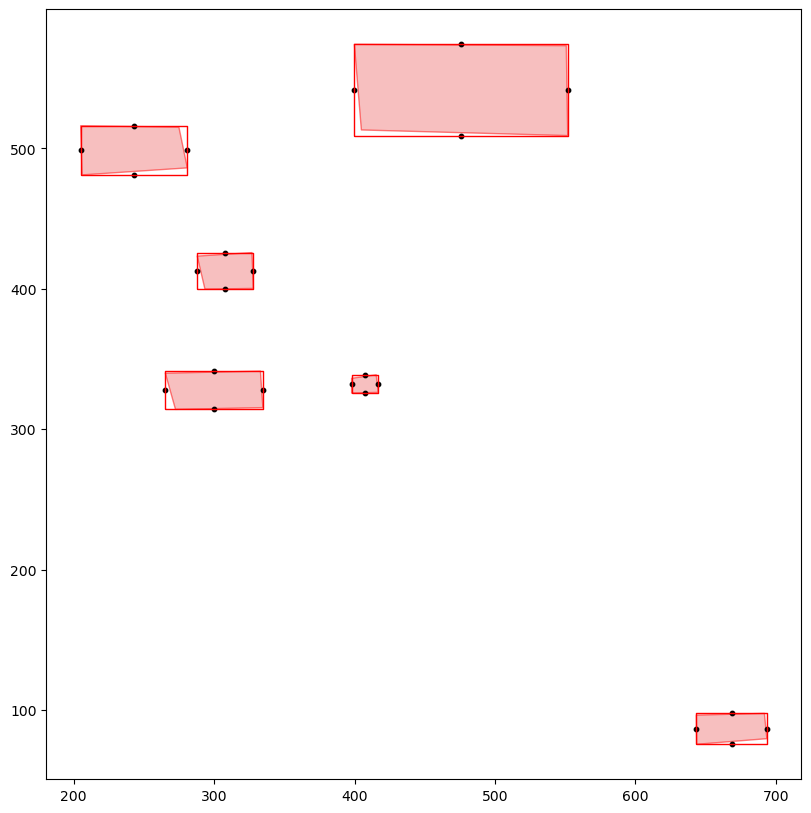

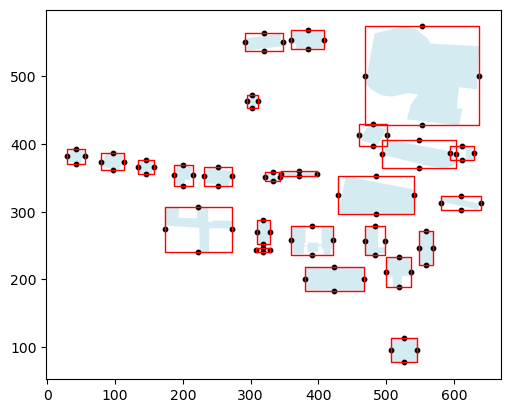

In [25]:
# Flatten the list of midpoints into a list of Shapely Points for plotting
all_mids_bsm = [Point(p) for sublist in bsm_gdf['midpoints'] for p in sublist]
mids_gs_bsm = gpd.GeoSeries(all_mids_bsm)

all_mids_skm = [Point(p) for sublist in skm_gdf['midpoints'] for p in sublist]
mids_gs_skm = gpd.GeoSeries(all_mids_skm)

ax = skm_gdf.geometry.plot(color='lightcoral', edgecolor='red', alpha=0.5, figsize=(10, 10))
skm_gdf.set_geometry('tight_bbox').boundary.plot(ax=ax, color='red', linewidth=1)
mids_gs_skm.plot(ax=ax, color='black', markersize=10) # Black dots at midpoints
ax = bsm_gdf.geometry.plot(color='lightblue', alpha=0.5)
bsm_gdf.set_geometry('tight_bbox').boundary.plot(ax=ax, color='red', linewidth=1)
mids_gs_bsm.plot(ax=ax, color='black', markersize=10) # Black dots at midpoints


## 4. Calculate BDR and GMDA - based measures

### First let's calculate GMDA - based measures

There are 6 GMDA-based measures
1. Canonical Organization (CanOrg)
2. Canonical Accuracy (CanAcc)
3. Scaling Bias (ScaBias)
4. Distance Accuracy (DistAcc)
5. Rotational Bias (RotBias)
6. Angle Accuracy (AngAcc)

### 1. Canonical Organization ( Basic and Advanced)

Make two versions of measures,
1. Centroid 
2. Representative point

For scientific paper, 
need to stick to the Original Gardony method. 

GMDA does not make enough sense, compared to SketchMapia. 

In [2]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import json 
import math
import pandas as pd


bsm_data = gpd.read_file(r"C:\Users\ajays\Downloads\Results (1)\GeneralizedBaseMap\AS_Sketch_1.jpg.geojson")
skm_data = gpd.read_file(r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\AS_Sketch_1.jpg.geojson")


def compute_mbr_points(geometry, otype, r_buffer=1):
    """Extract 8 MBR points for Polygon and CircleMarker"""
    if otype == 'Polygon':
        x_min, y_min, x_max, y_max = map(float, geometry.bounds)
    elif otype == 'CircleMarker':
        # CircleMarker is a point — create a small buffer around it
        coords = list(geometry.coords)[0]
        x, y = float(coords[0]), float(coords[1])
        x_min, x_max = x - r_buffer, x + r_buffer
        y_min, y_max = y - r_buffer, y + r_buffer
    else:
        return None

    return [
        [x_min, y_max],                     # up_left
        [(x_min + x_max) / 2, y_max],       # up_center
        [x_max, y_max],                     # up_right
        [x_max, (y_min + y_max) / 2],       # right_center
        [x_max, y_min],                     # down_right
        [(x_min + x_max) / 2, y_min],       # down_center
        [x_min, y_min],                     # down_left
        [x_min, (y_min + y_max) / 2],       # left_center
    ]

#Now, Minimum Bounding Rectangles for BaseMap

bsm_dict_mbr = {}
for i in range(bsm_data.shape[0]):
    otype = bsm_data.iloc[i]['otype']
    if otype in ['Polygon', 'CircleMarker']:
        id_poly = str(bsm_data.iloc[i]['id'])
        bsm_dict_mbr[id_poly] = compute_mbr_points(bsm_data.iloc[i]['geometry'], otype)

#print(bsm_dict_mbr)

#Similarly, Minimum Bounding Rectangles for SketchMap
skm_dict_mbr = {}
for i in range(skm_data.shape[0]):
    otype = skm_data.iloc[i]['otype']
    if otype in ['Polygon', 'CircleMarker']:
        id_poly = str(skm_data.iloc[i]['id'])
        skm_dict_mbr[id_poly] = compute_mbr_points(skm_data.iloc[i]['geometry'], otype)

#print(skm_dict_mbr)

def load_alignment_table(path, sketch_map_name, bsm_dict_mbr):
    """
    Reads an alignment table (CSV or Excel) and builds dict_align.
    Robust to extra whitespace and varying capitalization in column headers.
    Returns { basemap_id (str) : sketch_id (str) }
    """
    # Read CSV or Excel based on extension
    if path.lower().endswith('.csv'):
        try:
            df = pd.read_csv(path, dtype=str, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(path, dtype=str, encoding='latin-1')
    else:
        df = pd.read_excel(path, dtype=str)
    
    # --- Normalize column names so 'Sketch Map', 'SketchMap', 'sketch_map' all match ---
    df.columns = [str(c).strip() for c in df.columns]
    col_lookup = {c.lower().replace(' ', '').replace('_', ''): c for c in df.columns}
    
    def find_col(name):
        key = name.lower().replace(' ', '').replace('_', '')
        if key not in col_lookup:
            raise KeyError(
                f"Could not find a '{name}' column. Available columns: {df.columns.tolist()}"
            )
        return col_lookup[key]
    
    sm_col = find_col('Sketch Map')
    b_col  = find_col('BaseId')
    s_col  = find_col('SketchId')
    
    # Strip whitespace AND extension, compare case-insensitively
    def _norm(s):
        s = str(s).strip().lower()
        for ext in ('.jpg', '.jpeg', '.png'):
            if s.endswith(ext):
                s = s[:-len(ext)]
        return s

    target = _norm(sketch_map_name)
    df = df[df[sm_col].apply(_norm) == target]
    
    # Build the alignment dictionary (keep IDs as STRINGS to match geojson keys)
    dict_align = {}
    for _, row in df.iterrows():
        base_raw   = str(row[b_col]).strip()
        sketch_raw = str(row[s_col]).strip()
        
        # Skip "Features missing..." / "Features drawn extra..." rows
        if not sketch_raw.lower().startswith('s'):
            continue
        sk_num = sketch_raw[1:].strip()
        if not sk_num.isdigit():
            continue
        sk_id = sk_num                       # store as string, e.g. '5'
        
        # BaseId may contain multiple ids separated by spaces
        for tok in base_raw.split():
            if not tok.isdigit():
                continue
            bsm_id = tok                     # store as string, e.g. '17'
            
            if bsm_id in bsm_dict_mbr:
                dict_align[bsm_id] = sk_id
    
    return dict_align


# === Build the alignment dictionary from the table ===
dict_align = load_alignment_table(
    r"datasets\Data\Loc3\alignment.xlsx",      # or alignment.xlsx
    sketch_map_name='AS_Sketch_1.jpg',
    bsm_dict_mbr=bsm_dict_mbr
)

print(f"Loaded {len(dict_align)} aligned landmark pairs")


#print(dict_align)

#Calculating GMDA Measures

nTL = len(bsm_dict_mbr) # Number of Landmarks in BaseMap
nDL = len(dict_align) # Number of Landmarks in SketchMap


n_nTL = math.comb(8 * nTL, 2) - nTL * math.comb(8, 2)
n_nDL = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2)


def landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
    """ 
    Generates coordinate pairs only if the IDs exist in both dictionaries.
    """
    keys = list(dict_align.keys())

    for i in range(len(keys) - 1):
        k1 = keys[i] # Basemap ID 1
        
        # CHECK: Does k1 exist in Basemap and its partner exist in Sketchmap?
        if k1 not in bsm_dict_mbr or dict_align[k1] not in skm_dict_mbr:
            continue
            
        b1_pts = bsm_dict_mbr[k1]
        s1_pts = skm_dict_mbr[dict_align[k1]]

        for k2 in keys[i + 1:]: # Basemap ID 2
            
            # CHECK: Does k2 exist in Basemap and its partner exist in Sketchmap?
            if k2 not in bsm_dict_mbr or dict_align[k2] not in skm_dict_mbr:
                continue
                
            b2_pts = bsm_dict_mbr[k2]
            s2_pts = skm_dict_mbr[dict_align[k2]]
            
            for j in range(8):
                b1_x, b1_y = b1_pts[j]
                s1_x, s1_y = s1_pts[j]

                for l in range(8):
                    b2_x, b2_y = b2_pts[l]
                    s2_x, s2_y = s2_pts[l]
                    
                    yield b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y


#1. Canonical Score
def CanScore(dict_align, bsm_dict_mbr, skm_dict_mbr):
    """ 
    Calculates the Sum of Canonical Scores across all landmark pairs
    """
    sum_can_score = 0
    for b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y in landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
        #Checking for N and S
        if (b1_y < b2_y and s1_y < s2_y) or (b1_y > b2_y and s1_y > s2_y):
            sum_can_score += 1
        #Checking for E and W
        if (b1_x < b2_x and s1_x < s2_x) or (b1_x > b2_x and s1_x > s2_x):
            sum_can_score += 1
    return sum_can_score


print(f"Canonical Score: {CanScore(dict_align, bsm_dict_mbr, skm_dict_mbr)}")

#2. Canonical Organisation
def CanOrg(dict_align, bsm_dict_mbr, skm_dict_mbr):
    """ 
    Calculates the Canonical Organisation Score 

    CanOrg = sum(canonical Score) / 2 * n
    where, 
        n = C(8 * nTL, 2) - nTL * C(8, 2)
    """
    nTL = len(bsm_dict_mbr)
    n = math.comb(8 * nTL, 2) - nTL * math.comb(8, 2)
    sum_can_score = CanScore(dict_align, bsm_dict_mbr, skm_dict_mbr)

    return np.round(sum_can_score / (2 * n), 2)

#CanOrg(dict_align, bsm_dict_mbr, skm_dict_mbr)


#3. Canonical Accuracy
def CanAcc(dict_align, bsm_dict_mbr, skm_dict_mbr):
    """ 
    CanAcc = sum(canonical Score) / (2 * n)
    where, 
        n = C(8 * nDL, 2) - nDL * C(8, 2)
    
    """
    n = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2)
    sum_can_score = CanScore(dict_align, bsm_dict_mbr, skm_dict_mbr)

    return np.round(sum_can_score/(2 * n), 2)

#CanAcc(dict_align, bsm_dict_mbr, skm_dict_mbr)

#4. Scaling Bias
def ScaBias(dict_align, bsm_dict_mbr, skm_dict_mbr):
    """ 
    ScaBias = sum( drawn_sketch / maxD_sketch - dr_base / maxD_base) / n
    """
    nDL = len(dict_align)
    n = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2)

    #First: find max distances
    max_D_bsm, max_D_skm = 0, 0
    for b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y in landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
        dist_bsm = np.sqrt((b1_x - b2_x)**2 + (b1_y - b2_y)**2)
        dist_skm = np.sqrt((s1_x - s2_x)**2 + (s1_y - s2_y)**2)

        if dist_bsm > max_D_bsm:
            max_D_bsm = dist_bsm 
        if dist_skm > max_D_skm:
            max_D_skm = dist_skm

    #Second: computing normalized differences
    sum_dr_diff = 0
    for b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y in landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
        dist_bsm = np.sqrt((b1_x - b2_x)**2 + (b1_y - b2_y)**2)
        dist_skm = np.sqrt((s1_x - s2_x)**2 + (s1_y - s2_y)**2)
        sum_dr_diff += dist_skm / max_D_skm - dist_bsm / max_D_bsm

    return np.round(sum_dr_diff / n, 2)

#ScaBias(dict_align, bsm_dict_mbr, skm_dict_mbr) 

#5. Distance Accuracy
def DistAcc(dict_align, bsm_dict_mbr, skm_dict_mbr):
    nDL = len(dict_align)
    n = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2)

    #First: find max distances
    max_D_bsm, max_D_skm = 0, 0
    for b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y in landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
        dist_bsm = np.sqrt((b1_x - b2_x)**2 + (b1_y - b2_y)**2)
        dist_skm = np.sqrt((s1_x - s2_x)**2 + (s1_y - s2_y)**2)

        if dist_bsm > max_D_bsm:
            max_D_bsm = dist_bsm 
        if dist_skm > max_D_skm:
            max_D_skm = dist_skm

    #Second: computing normalized differences
    sum_dr_diff_abs = 0
    for b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y in landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
        dist_bsm = np.sqrt((b1_x - b2_x)**2 + (b1_y - b2_y)**2)
        dist_skm = np.sqrt((s1_x - s2_x)**2 + (s1_y - s2_y)**2)
        sum_dr_diff_abs += np.abs(dist_skm / max_D_skm - dist_bsm / max_D_bsm)

    return np.round((1 - (sum_dr_diff_abs/n)), 2)

#DistAcc(dict_align, bsm_dict_mbr, skm_dict_mbr)

#6. Rotational Bias

def RotBias(dict_align, bsm_dict_mbr, skm_dict_mbr):
    """ 
    RotBias = arctan2(mean(sin(ang_diff)), mean (cos(ang_diff))) in degrees.
    """
    nDL = len(dict_align)
    n = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2)

    sum_sin, sum_cos = 0, 0 
    for b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y in landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
        ang_bsm = np.arctan2(b2_x - b1_x, b2_y - b1_y)
        ang_skm = np.arctan2(s2_x - s1_x, s2_y - s1_y)

        ang_diff = ang_skm - ang_bsm

        while ang_diff < -np.pi:
            ang_diff += (2 * np.pi)
        while ang_diff > np.pi:
            ang_diff -= (2 * np.pi)

        sum_sin += np.sin(ang_diff)
        sum_cos += np.cos(ang_diff)

    return np.round(180 / np.pi * np.arctan2(sum_sin / n, sum_cos / n), 2)

#RotBias(dict_align, bsm_dict_mbr, skm_dict_mbr) 
    
#7. Angular Accuracy

def AngAcc(dict_align, bsm_dict_mbr, skm_dict_mbr):
    """ 
    Calculates the Angular Accuracy, AngAcc = 1 - sum (|ang_diff_degrees|) / (180 * n)
    """
    nDL = len(dict_align)
    n = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2)

    sum_diff_abs = 0
    for b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y in landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
        ang_bsm = np.arctan2(b2_x - b1_x, b2_y - b1_y)
        ang_skm = np.arctan2(s2_x - s1_x, s2_y - s1_y)

        ang_diff = ang_skm - ang_bsm

        while ang_diff < -np.pi:
            ang_diff += (2 * np.pi)
        while ang_diff > np.pi:
            ang_diff -= (2 * np.pi) 

        sum_diff_abs += np.abs(180 / np.pi * ang_diff)

    return np.round(1 - sum_diff_abs / (180 * n), 2)

#AngAcc(dict_align, bsm_dict_mbr, skm_dict_mbr)


print(f"Canonical Organization Score:    {CanOrg(dict_align, bsm_dict_mbr, skm_dict_mbr)}")
print(f"Canonical Accuracy Score:        {CanAcc(dict_align, bsm_dict_mbr, skm_dict_mbr)}")
print(f"Scaling Bias Score:              {ScaBias(dict_align, bsm_dict_mbr, skm_dict_mbr)}")
print(f"Distance Accuracy Score:         {DistAcc(dict_align, bsm_dict_mbr, skm_dict_mbr)}")
print(f"Rotational Bias Score:           {RotBias(dict_align, bsm_dict_mbr, skm_dict_mbr)}")
print(f"Angle Accuracy Score:            {AngAcc(dict_align, bsm_dict_mbr, skm_dict_mbr)}")




Skipping field BaseAlign: unsupported OGR type: 1
Skipping field SketchAlign: unsupported OGR type: 5


Loaded 1 aligned landmark pairs
Canonical Score: 0
Canonical Organization Score:    0.0


ZeroDivisionError: division by zero

In [54]:
# What IDs are actually in your basemap?
print("All IDs in basemap:", sorted(bsm_dict_mbr.keys(), key=lambda x: int(x) if x.isdigit() else -1))
print()

# What does the Excel say we need?
excel_baseids = ['17','16','0','8','38','26','43','44','34','35','33','32',
                 '65','48','55','53','2','3','5','25','70','73']
print("Needed by Excel:    ", sorted(excel_baseids, key=int))
print()

# Which ones are missing from the basemap?
missing = [b for b in excel_baseids if b not in bsm_dict_mbr]
print(f"Missing from basemap ({len(missing)}/{len(excel_baseids)}):", sorted(missing, key=int))

All IDs in basemap: ['9', '11', '12', '13', '17', '18', '110159', '110160', '110161', '110162', '110163', '110164', '110165', '110166', '110167', '110168', '110169', '110170', '110171', '110172', '110173', '110174', '110175', '110176', '110177']

Needed by Excel:     ['0', '2', '3', '5', '8', '16', '17', '25', '26', '32', '33', '34', '35', '38', '43', '44', '48', '53', '55', '65', '70', '73']

Missing from basemap (21/22): ['0', '2', '3', '5', '8', '16', '25', '26', '32', '33', '34', '35', '38', '43', '44', '48', '53', '55', '65', '70', '73']


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import math

def compute_mbr_points(geometry, otype, r_buffer=1):
    """Exact MBR logic from Script 1."""
    if geometry is None or geometry.is_empty:
        return None
    if otype == 'Polygon':
        x_min, y_min, x_max, y_max = map(float, geometry.bounds)
    elif otype == 'CircleMarker':
        coords = list(geometry.coords)[0]
        x, y = float(coords[0]), float(coords[1])
        x_min, x_max = x - r_buffer, x + r_buffer
        y_min, y_max = y - r_buffer, y + r_buffer
    else:
        return None

    return [
        [x_min, y_max], [(x_min + x_max) / 2, y_max], [x_max, y_max],
        [x_max, (y_min + y_max) / 2], [x_max, y_min],
        [(x_min + x_max) / 2, y_min], [x_min, y_min],
        [x_min, (y_min + y_max) / 2],
    ]

def landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
    keys = list(dict_align.keys())
    for i in range(len(keys) - 1):
        k1 = keys[i]
        if k1 not in bsm_dict_mbr or dict_align[k1] not in skm_dict_mbr:
            continue
        b1_pts, s1_pts = bsm_dict_mbr[k1], skm_dict_mbr[dict_align[k1]]

        for j in range(i + 1, len(keys)):
            k2 = keys[j]
            if k2 not in bsm_dict_mbr or dict_align[k2] not in skm_dict_mbr:
                continue
            b2_pts, s2_pts = bsm_dict_mbr[k2], skm_dict_mbr[dict_align[k2]]
            
            for p in range(8):
                b1_x, b1_y = b1_pts[p]
                s1_x, s1_y = s1_pts[p]
                for l in range(8):
                    b2_x, b2_y = b2_pts[l]
                    s2_x, s2_y = s2_pts[l]
                    yield b1_x, b1_y, b2_x, b2_y, s1_x, s1_y, s2_x, s2_y

def run_gmda_math(dict_align, bsm_dict_mbr, skm_dict_mbr):
    """Aggregated GMDA metrics following original logic."""
    nTL = len(bsm_dict_mbr)
    nDL = len(dict_align)
    n_nTL = math.comb(8 * nTL, 2) - nTL * math.comb(8, 2)
    n_nDL = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2)

    sum_can_score, sum_sin, sum_cos, sum_diff_abs = 0, 0, 0, 0
    max_D_bsm, max_D_skm = 1e-9, 1e-9
    pairs_data = []

    for b1x, b1y, b2x, b2y, s1x, s1y, s2x, s2y in landmark_pairs(dict_align, bsm_dict_mbr, skm_dict_mbr):
        if (b1y < b2y and s1y < s2y) or (b1y > b2y and s1y > s2y): sum_can_score += 1
        if (b1x < b2x and s1x < s2x) or (b1x > b2x and s1x > s2x): sum_can_score += 1
        
        d_bsm = np.sqrt((b1x - b2x)**2 + (b1y - b2y)**2)
        d_skm = np.sqrt((s1x - s2x)**2 + (s1y - s2y)**2)
        max_D_bsm = max(max_D_bsm, d_bsm)
        max_D_skm = max(max_D_skm, d_skm)
        pairs_data.append((d_bsm, d_skm))

        ang_bsm = np.arctan2(b2x - b1x, b2y - b1y)
        ang_skm = np.arctan2(s2x - s1x, s2y - s1y)
        ang_diff = ang_skm - ang_bsm
        while ang_diff < -np.pi: ang_diff += (2 * np.pi)
        while ang_diff > np.pi: ang_diff -= (2 * np.pi)
        
        sum_sin += np.sin(ang_diff)
        sum_cos += np.cos(ang_diff)
        sum_diff_abs += np.abs(np.degrees(ang_diff))

    sum_dr_diff = sum([(ds/max_D_skm - db/max_D_bsm) for db, ds in pairs_data])
    sum_dr_diff_abs = sum([abs(ds/max_D_skm - db/max_D_bsm) for db, ds in pairs_data])

    return {
        'CanScore': sum_can_score,
        'CanOrg': np.round(sum_can_score / (2 * n_nTL), 2) if n_nTL > 0 else 0,
        'CanAcc': np.round(sum_can_score / (2 * n_nDL), 2) if n_nDL > 0 else 0,
        'ScaBias': np.round(sum_dr_diff / n_nDL, 2) if n_nDL > 0 else 0,
        'DistAcc': np.round(1 - (sum_dr_diff_abs / n_nDL), 2) if n_nDL > 0 else 0,
        'RotBias': np.round(np.degrees(np.arctan2(sum_sin/n_nDL, sum_cos/n_nDL)), 2) if n_nDL > 0 else 0,
        'AngAcc': np.round(1 - sum_diff_abs / (180 * n_nDL), 2) if n_nDL > 0 else 0
    }

def process_folder(folder_path):
    files = os.listdir(folder_path)
    bsm_path = next((os.path.join(folder_path, f) for f in files if 'location1.png.geojson' in f), None)
    aln_path = next((os.path.join(folder_path, f) for f in files if f == 'alignment.json'), None)
    
    if not bsm_path or not aln_path: return "Files missing."

    bsm_data = gpd.read_file(bsm_path)
    with open(aln_path, 'r') as f: full_align = json.load(f)

    # 1. Build Basemap Dict exactly as script 1
    bsm_dict_mbr = {}
    for i in range(len(bsm_data)):
        row = bsm_data.iloc[i]
        if row.get('aligned') == True and row['otype'] in ['Polygon', 'CircleMarker']:
            mbr = compute_mbr_points(row.geometry, row['otype'])
            if mbr: bsm_dict_mbr[row['id']] = mbr

    final_results = []
    for f_name in files:
        if f_name.endswith('.geojson') and 'location1' not in f_name:
            target_key = f_name.replace('.geojson', '')
            if target_key not in full_align: continue
            
            skm_data = gpd.read_file(os.path.join(folder_path, f_name))
            
            # 2. Build Sketch Dict exactly as script 1 (matching row indices of Basemap)
            skm_dict_mbr = {}
            for i in range(min(len(skm_data), len(bsm_data))):
                sk_row = skm_data.iloc[i]
                # Script 1 uses bsm_data[i].aligned to filter skm_data[i]
                if bsm_data.iloc[i].get('aligned') == True and sk_row['otype'] in ['Polygon', 'CircleMarker']:
                    mbr = compute_mbr_points(sk_row.geometry, sk_row['otype'])
                    if mbr: skm_dict_mbr[sk_row['id']] = mbr

            # 3. Build Alignment Mapping using the specific [1:] slice
            dict_align = {}
            align_block = full_align[target_key]
            for al_id in align_block:
                if al_id == 'checkAlignnum': continue
                
                bsm_keys = align_block[al_id]['BaseAlign']['0']
                skm_val_list = align_block[al_id]['SketchAlign']['0']
                
                # REPLICATING: int(skm_value[0][1:])
                try:
                    raw_val = str(skm_val_list[0])
                    sk_id = int(raw_val[1:]) 
                except: continue
                
                for k in bsm_keys:
                    # Filter check like Script 1
                    if k in bsm_dict_mbr:
                        dict_align[k] = sk_id

            if len(dict_align) >= 2:
                stats = run_gmda_math(dict_align, bsm_dict_mbr, skm_dict_mbr)
                stats['ID'] = target_key
                final_results.append(stats)

    return pd.DataFrame(final_results).set_index('ID')

df = process_folder(r'datasets\Data\Loc1')
print(df)

                  CanScore  CanOrg  CanAcc  ScaBias  DistAcc  RotBias  AngAcc
ID                                                                           
AS_Sketch_1.jpg      36247    0.57    0.57     0.01     0.93   -22.57    0.69
AS_Sketch_10.jpg     39954    0.63    0.63    -0.00     0.92   -23.50    0.68
AS_Sketch_2.jpg      32939    0.52    0.52     0.00     0.94   -21.78    0.70
AS_Sketch_3.jpg      32580    0.51    0.59     0.00     0.93   -19.37    0.67
AS_Sketch_4.jpg      25767    0.41    0.41     0.01     0.88   -15.14    0.73
AS_Sketch_5.jpg        390    0.01    0.01     0.00     1.00   -13.17    1.00
AS_Sketch_6.jpg      25892    0.41    0.50     0.01     0.94   -26.20    0.65
AS_Sketch_7.jpg      40362    0.64    0.64     0.00     0.93   -19.87    0.69
AS_Sketch_8.jpg      39777    0.63    0.63    -0.00     0.94   -25.58    0.68
AS_Sketch_9.jpg      29053    0.46    0.46     0.02     0.93   -27.55    0.70
CM_Sketch_1.jpg      36284    0.57    0.57     0.01     0.93   -

Canonical Score: 36247
Canonical Organization Score:    0.57
Canonical Accuracy Score:        0.57
Scaling Bias Score:              0.01
Distance Accuracy Score:         0.93
Rotational Bias Score:           -22.57
Angle Accuracy Score:            0.69

In [17]:
import re

# ---------------------------------------------------------------------------
# Single source of truth for basemap filename detection.
# Matches things like:
#   location1.png.geojson, _location2.jpg.geojson, basemap.png.geojson, ...
# ---------------------------------------------------------------------------
BASEMAP_PATTERN = re.compile(
    r'((_location|location)\d+|basemap)\.(png|jpg|jpeg)\.geojson$',
    re.IGNORECASE
)


def process_folder(folder_path):
    files = os.listdir(folder_path)
    
    # Generic basemap detection (uses shared BASEMAP_PATTERN)
    bsm_file = next((f for f in files if BASEMAP_PATTERN.match(f)), None)
    aln_file = next((f for f in files if f == 'alignment.json'), None)
    
    if not bsm_file or not aln_file:
        print(f"  [Skip] Missing basemap or alignment in {folder_path}")
        return pd.DataFrame()

    bsm_path = os.path.join(folder_path, bsm_file)
    aln_path = os.path.join(folder_path, aln_file)

    bsm_data = gpd.read_file(bsm_path)
    with open(aln_path, 'r') as f: full_align = json.load(f)

    # 1. Build Basemap Dict exactly as script 1
    bsm_dict_mbr = {}
    for i in range(len(bsm_data)):
        row = bsm_data.iloc[i]
        if row.get('aligned') == True and row['otype'] in ['Polygon', 'CircleMarker']:
            mbr = compute_mbr_points(row.geometry, row['otype'])
            if mbr: bsm_dict_mbr[row['id']] = mbr

    final_results = []
    for f_name in files:
        # Skip the basemap itself; only treat the rest as sketchmaps
        if f_name.endswith('.geojson') and f_name != bsm_file:
            target_key = f_name.replace('.geojson', '')
            if target_key not in full_align: continue
            
            skm_data = gpd.read_file(os.path.join(folder_path, f_name))
            
            # 2. Build Sketch Dict exactly as script 1 (matching row indices of Basemap)
            skm_dict_mbr = {}
            for i in range(min(len(skm_data), len(bsm_data))):
                sk_row = skm_data.iloc[i]
                # Script 1 uses bsm_data[i].aligned to filter skm_data[i]
                if bsm_data.iloc[i].get('aligned') == True and sk_row['otype'] in ['Polygon', 'CircleMarker']:
                    mbr = compute_mbr_points(sk_row.geometry, sk_row['otype'])
                    if mbr: skm_dict_mbr[sk_row['id']] = mbr

            # 3. Build Alignment Mapping using the specific [1:] slice
            dict_align = {}
            align_block = full_align[target_key]
            for al_id in align_block:
                if al_id == 'checkAlignnum': continue
                
                bsm_keys = align_block[al_id]['BaseAlign']['0']
                skm_val_list = align_block[al_id]['SketchAlign']['0']
                
                # REPLICATING: int(skm_value[0][1:])
                try:
                    raw_val = str(skm_val_list[0])
                    sk_id = int(raw_val[1:]) 
                except: continue
                
                for k in bsm_keys:
                    # Filter check like Script 1
                    if k in bsm_dict_mbr:
                        dict_align[k] = sk_id

            if len(dict_align) >= 2:
                stats = run_gmda_math(dict_align, bsm_dict_mbr, skm_dict_mbr)
                stats['ID'] = target_key
                final_results.append(stats)

    return pd.DataFrame(final_results)


def process_all_folders(root_path, output_csv='gmda_results.csv'):
    """Walk through root_path, process every subfolder, write each folder as its own table in the CSV."""
    folder_results = {}  # {folder_label: dataframe}
    
    # Walk through every subdirectory under the root
    for dirpath, dirnames, filenames in os.walk(root_path):
        # Detect a valid folder: must have a basemap + alignment.json (uses shared BASEMAP_PATTERN)
        has_bsm = any(BASEMAP_PATTERN.match(f) for f in filenames)
        has_aln = 'alignment.json' in filenames
        
        if has_bsm and has_aln:
            # Use folder name relative to root as a label
            folder_label = os.path.relpath(dirpath, root_path)
            print(f"Processing: {folder_label}")
            
            df_folder = process_folder(dirpath)
            if not df_folder.empty:
                folder_results[folder_label] = df_folder
    
    if not folder_results:
        print("No valid folders found.")
        return {}
    
    # Write each folder's table sequentially into the CSV with a section header
    with open(output_csv, 'w', newline='', encoding='utf-8') as f:
        for folder_label, df_folder in folder_results.items():
            f.write(f"### Folder: {folder_label}\n")    # section header
            df_folder.to_csv(f, index=False)
            f.write("\n")                               # blank line between tables
    
    print(f"\nResults written to: {output_csv}")
    print(f"Total folders: {len(folder_results)}")
    return folder_results


# Run on the root directory containing all the location folders
results = process_all_folders(r'datasets\Data', output_csv='gmda_results.csv')

Processing: Loc0
Processing: Loc1
Processing: Loc2
Processing: Loc3
Processing: Loc4
Processing: Loc5

Results written to: gmda_results.csv
Total folders: 6


# New Code for New File


GMDA DATASET STATS
----------------------------------------------------------------------
nTL (Total Basemap Landmarks)   : 25
nDL (Aligned Sketch Landmarks)  : 8
SketchId    BasemapIDs               Type      
----------------------------------------------------------------------
S2          53                       1:1       
S4          73                       1:1       
S12         48                       1:1       
S17         67                       1:1       
S22         66                       1:1       
S26         65                       1:1       
S27         56, 55                   many      
----------------------------------------------------------------------
 1:1 pairs    : 6
 many-to-one : 1
Canonical Score               : 3414
Canonical Organization Score  : 0.09
Canonical Accuracy Score      : 0.95
Scaling Bias Score            : 0.06
Distance Accuracy Score       : 0.92
Rotational Bias Score         : -5.57
Angle Accuracy Score          : 0.94


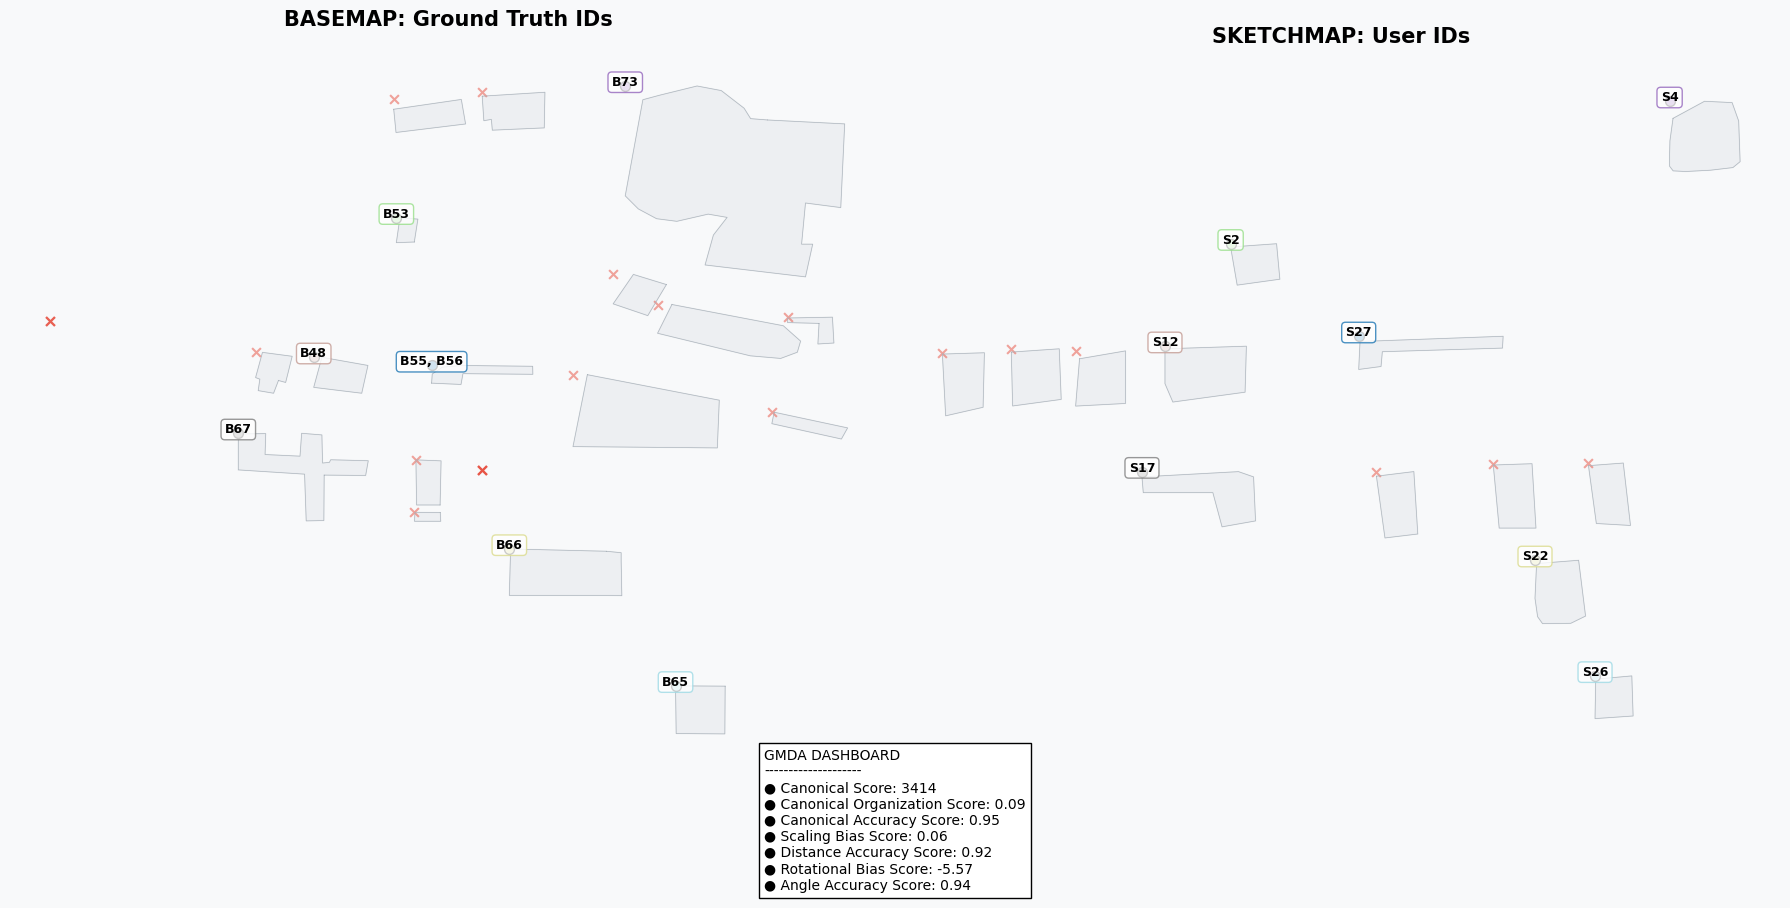

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json
import math
import pandas as pd
from shapely.geometry import shape
from matplotlib.offsetbox import AnchoredText

# =============================================================================
# FILE PATHS
# =============================================================================
BSM_PATH = r"C:\Users\ajays\Downloads\Results (1)\GeneralizedBaseMap\AS_Sketch_3.jpg.geojson"
SKM_PATH = r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\AS_Sketch_3.jpg.geojson"

# =============================================================================
# HELPERS & DATA LOADING
# =============================================================================

def load_geojson_with_align(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for feat in data['features']:
        props = (feat.get('properties') or {}).copy()
        props['geometry'] = shape(feat['geometry'])
        rows.append(props)
    return rows

def _normalize_align_value(v):
    if v is None: return []
    if isinstance(v, (list, tuple)):
        out = []
        for x in v: out.extend(_normalize_align_value(x))
        return out
    s = str(v).strip()
    if s.lower().startswith('s') and s[1:].isdigit(): s = s[1:]
    return [s] if s else []

def compute_mbr_points(geometry, otype, r_buffer=1):
    if otype == 'Polygon':
        x_min, y_min, x_max, y_max = map(float, geometry.bounds)
    elif otype == 'CircleMarker':
        coords = list(geometry.coords)[0]
        x, y = float(coords[0]), float(coords[1])
        x_min, x_max = x - r_buffer, x + r_buffer
        y_min, y_max = y - r_buffer, y + r_buffer
    else: return None
    return [[x_min, y_max], [(x_min + x_max) / 2, y_max], [x_max, y_max],
            [x_max, (y_min + y_max) / 2], [x_max, y_min], [(x_min + x_max) / 2, y_min],
            [x_min, y_min], [x_min, (y_min + y_max) / 2]]

# Load data
bsm_rows = load_geojson_with_align(BSM_PATH)
skm_rows = load_geojson_with_align(SKM_PATH)

# Build MBR Lookups
bsm_dict_mbr = {}
for row in bsm_rows:
    if row.get('otype') not in ('Polygon', 'CircleMarker'): continue
    mbr = compute_mbr_points(row['geometry'], row['otype'])
    if mbr:
        base_ids = _normalize_align_value(row.get('BaseAlign')) or [str(row.get('id'))]
        for bid in base_ids: bsm_dict_mbr[bid] = mbr

skm_dict_mbr = {}
for row in skm_rows:
    if row.get('otype') not in ('Polygon', 'CircleMarker'): continue
    mbr = compute_mbr_points(row['geometry'], row['otype'])
    if mbr: skm_dict_mbr[str(row.get('id'))] = mbr

# =============================================================================
# ALIGNMENT & REPORTING
# =============================================================================

verified_pairs = []
pairs_by_sk = {}

for row in bsm_rows:
    if not row.get('aligned') or row.get('genType') in ('Abstraction to show existence buildings') or row.get('otype') not in ('Polygon', 'CircleMarker') : continue
    b_ids = _normalize_align_value(row.get('BaseAlign'))
    s_ids = _normalize_align_value(row.get('SketchAlign'))
    if not b_ids or not s_ids: continue
    
    sk_id = s_ids[0] 
    for bid in b_ids:
        if bid in bsm_dict_mbr and sk_id in skm_dict_mbr:
            verified_pairs.append((bid, sk_id))
            pairs_by_sk.setdefault(sk_id, []).append(bid)

# Print Detailed Report
print("\n" + "=" * 70)
print(f"GMDA DATASET STATS")
print("-" * 70)
nTL = len(bsm_dict_mbr)
nDL = len(verified_pairs)
print(f"nTL (Total Basemap Landmarks)   : {nTL}")
print(f"nDL (Aligned Sketch Landmarks)  : {nDL}")
print("=" * 70)

print(f"{'SketchId':<12}{'BasemapIDs':<25}{'Type':<10}")
print("-" * 70)
for sk_id in sorted(pairs_by_sk.keys(), key=lambda x: int(x) if x.isdigit() else 9999):
    b_list = pairs_by_sk[sk_id]
    print(f"S{sk_id:<11}{', '.join(b_list):<25}{('many' if len(b_list)>1 else '1:1'):<10}")
print("-" * 70)
print(f" 1:1 pairs    : {sum(1 for v in pairs_by_sk.values() if len(v) == 1)}")
print(f" many-to-one : {sum(1 for v in pairs_by_sk.values() if len(v) > 1)}")
print("=" * 70)

# CSV Export
# pd.DataFrame([{
#     'SketchId': f"S{sid}", 'BasemapIDs': ', '.join(bids), 'Type': 'many' if len(bids) > 1 else '1:1'
# } for sid, bids in pairs_by_sk.items()]).to_csv('common_pairs.csv', index=False)
# print(f"Saved {len(pairs_by_sk)} sketch-landmark groups to 'common_pairs.csv'\n")

# =============================================================================
# GMDA CALCULATIONS
# =============================================================================

def landmark_pairs_generator(v_pairs, b_mbr, s_mbr):
    for i in range(len(v_pairs) - 1):
        b1, s1 = v_pairs[i]
        for j in range(i + 1, len(v_pairs)):
            b2, s2 = v_pairs[j]
            b1_pts, s1_pts = b_mbr[b1], s_mbr[s1]
            b2_pts, s2_pts = b_mbr[b2], s_mbr[s2]
            for p1 in range(8):
                for p2 in range(8):
                    yield b1_pts[p1][0], b1_pts[p1][1], b2_pts[p2][0], b2_pts[p2][1], \
                          s1_pts[p1][0], s1_pts[p1][1], s2_pts[p2][0], s2_pts[p2][1]

pairs_gen = list(landmark_pairs_generator(verified_pairs, bsm_dict_mbr, skm_dict_mbr))
n_nTL = math.comb(8 * nTL, 2) - nTL * math.comb(8, 2) if nTL > 1 else 0
n_nDL = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2) if nDL > 1 else 0

def calculate_metrics():
    if not pairs_gen: return {}
    sum_can, sum_dist_abs, sum_sca_bias, sum_rot_sin, sum_rot_cos, sum_ang_abs = 0, 0, 0, 0, 0, 0
    max_db, max_ds = 0.001, 0.001
    
    for b1x, b1y, b2x, b2y, s1x, s1y, s2x, s2y in pairs_gen:
        max_db = max(max_db, np.sqrt((b1x-b2x)**2 + (b1y-b2y)**2))
        max_ds = max(max_ds, np.sqrt((s1x-s2x)**2 + (s1y-s2y)**2))

    for b1x, b1y, b2x, b2y, s1x, s1y, s2x, s2y in pairs_gen:
        if (b1y < b2y and s1y < s2y) or (b1y > b2y and s1y > s2y): sum_can += 1
        if (b1x < b2x and s1x < s2x) or (b1x > b2x and s1x > s2x): sum_can += 1
        db, ds = np.sqrt((b1x-b2x)**2 + (b1y-b2y)**2)/max_db, np.sqrt((s1x-s2x)**2 + (s1y-s2y)**2)/max_ds
        sum_sca_bias += (ds - db)
        sum_dist_abs += abs(ds - db)
        ang_b, ang_s = np.arctan2(b2x-b1x, b2y-b1y), np.arctan2(s2x-s1x, s2y-s1y)
        d = (ang_s - ang_b + np.pi) % (2 * np.pi) - np.pi
        sum_rot_sin += np.sin(d); sum_rot_cos += np.cos(d)
        sum_ang_abs += abs(np.degrees(d))

    return {
        "Canonical Score": sum_can,
        "Canonical Organization Score": round(sum_can / (2 * n_nTL), 2) if n_nTL > 0 else 0,
        "Canonical Accuracy Score": round(sum_can / (2 * n_nDL), 2) if n_nDL > 0 else 0,
        "Scaling Bias Score": round(sum_sca_bias / n_nDL, 2) if n_nDL > 0 else 0,
        "Distance Accuracy Score": round(1 - (sum_dist_abs / n_nDL), 2) if n_nDL > 0 else 0,
        "Rotational Bias Score": round(np.degrees(np.arctan2(sum_rot_sin, sum_rot_cos)), 2),
        "Angle Accuracy Score": round(1 - sum_ang_abs / (180 * n_nDL), 2) if n_nDL > 0 else 0
    }

metrics = calculate_metrics()
for name, value in metrics.items(): print(f"{name:<30}: {value}")

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_refined_alignment(bsm_rows, skm_rows, v_pairs, b_mbr, s_mbr, res):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), facecolor='#f8f9fa')
    cmap = plt.get_cmap('tab20', len(v_pairs))
    
    for ax, rows, mbr_lookup, title, p_idx, prefix in [
        (ax1, bsm_rows, b_mbr, "BASEMAP: Ground Truth IDs", 0, "B"),
        (ax2, skm_rows, s_mbr, "SKETCHMAP: User IDs", 1, "S")
    ]:
        ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
        for row in rows:
            if row['geometry'].geom_type == 'Polygon':
                ax.fill(*row['geometry'].exterior.xy, color='#dee2e6', alpha=0.4)
                ax.plot(*row['geometry'].exterior.xy, color='#adb5bd', linewidth=0.5)
        
        coord_labels = {} 
        for idx, pair in enumerate(v_pairs):
            tid = pair[p_idx]
            if tid in mbr_lookup:
                anchor = tuple(mbr_lookup[tid][0])
                if anchor not in coord_labels: coord_labels[anchor] = {'ids': set(), 'color': cmap(idx)}
                coord_labels[anchor]['ids'].add(f"{prefix}{tid}")

        for (x, y), data in coord_labels.items():
            txt = ", ".join(sorted(data['ids']))
            ax.scatter(x, y, s=50, color=data['color'], edgecolor='black', zorder=10)
            ax.text(x, y + 0.2, txt, fontsize=9, fontweight='bold', ha='center', zorder=11,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor=data['color'], boxstyle='round'))

        for tid, pts in mbr_lookup.items():
            if not any(tid == p[p_idx] for p in v_pairs):
                ax.scatter(pts[0][0], pts[0][1], s=40, color='#e74c3c', marker='x', alpha=0.5)
        ax.set_aspect('equal'); ax.axis('off')

    dashboard = "\n".join([f"● {k}: {v}" for k, v in res.items() if "Score" in k])
    fig.add_artist(AnchoredText(f"GMDA DASHBOARD\n{'-'*20}\n{dashboard}", loc='lower center', 
                                bbox_to_anchor=(0.5, -0.05), bbox_transform=fig.transFigure))
    plt.tight_layout(rect=[0, 0.05, 1, 0.95]); plt.show()

plot_refined_alignment(bsm_rows, skm_rows, verified_pairs, bsm_dict_mbr, skm_dict_mbr, metrics)


SKM ID     | Status       | Base ID         | Relationship Check
-------------------------------------------------------------------------------------------------------------------
S2         | 1:1 ALIGNED  | 53              | Unique relationship confirmed.
S4         | 1:1 ALIGNED  | 73              | Unique relationship confirmed.
S12        | 1:1 ALIGNED  | 48              | Unique relationship confirmed.
S14        | EXCLUDED     | G12             | Many-to-One: Base is shared by 3 sketches.
S15        | EXCLUDED     | G12             | Many-to-One: Base is shared by 3 sketches.
S16        | EXCLUDED     | G12             | Many-to-One: Base is shared by 3 sketches.
S17        | 1:1 ALIGNED  | 67              | Unique relationship confirmed.
S18        | EXCLUDED     | 27              | Many-to-One: Base is shared by 2 sketches.
S22        | 1:1 ALIGNED  | 66              | Unique relationship confirmed.
S23        | EXCLUDED     | G19             | Many-to-One: Base is shared by 

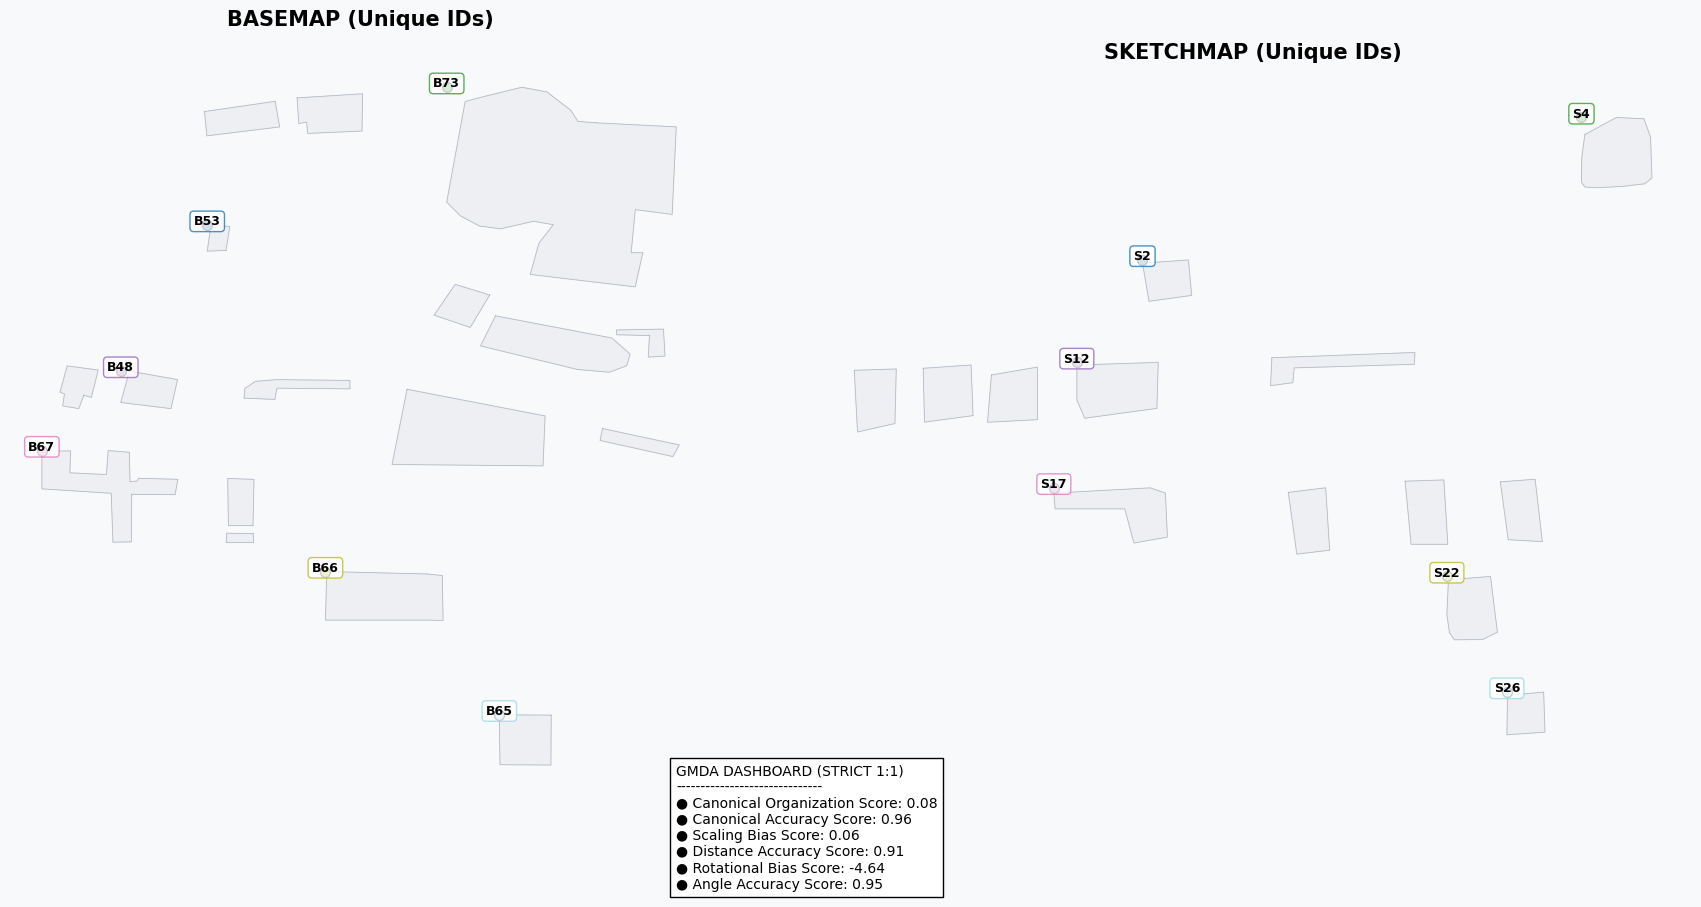

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import json
import math
import pandas as pd
from shapely.geometry import shape
from matplotlib.offsetbox import AnchoredText

# =============================================================================
# FILE PATHS
# =============================================================================
BSM_PATH = r"C:\Users\ajays\Downloads\Results (1)\GeneralizedBaseMap\AS_Sketch_3.jpg.geojson"
SKM_PATH = r"A:\IFGI-internship\SketchMapia\sketchMap_bdr\SketchMap\datasets\Data\Loc3\AS_Sketch_3.jpg.geojson"

# =============================================================================
# HELPERS & DATA LOADING
# =============================================================================

def load_geojson_with_align(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for feat in data['features']:
        props = (feat.get('properties') or {}).copy()
        props['geometry'] = shape(feat['geometry'])
        rows.append(props)
    return rows

def _normalize_align_value(v):
    if v is None: return []
    if isinstance(v, (list, tuple)):
        out = []
        for x in v: out.extend(_normalize_align_value(x))
        return out
    s = str(v).strip()
    if s.lower().startswith('s') and s[1:].isdigit(): s = s[1:]
    return [s] if s else []

def compute_mbr_points(geometry, otype, r_buffer=1):
    if otype == 'Polygon':
        x_min, y_min, x_max, y_max = map(float, geometry.bounds)
    elif otype == 'CircleMarker':
        coords = list(geometry.coords)[0]
        x, y = float(coords[0]), float(coords[1])
        x_min, x_max = x - r_buffer, x + r_buffer
        y_min, y_max = y - r_buffer, y + r_buffer
    else: return None
    return [[x_min, y_max], [(x_min + x_max) / 2, y_max], [x_max, y_max],
            [x_max, (y_min + y_max) / 2], [x_max, y_min], [(x_min + x_max) / 2, y_min],
            [x_min, y_min], [x_min, (y_min + y_max) / 2]]

def get_base_ids(row):
    gen_type = str(row.get('genType') or '').strip().lower()
    if 'amalgamation' in gen_type or 'abstraction' in gen_type:
        return [str(row.get('id'))]
    return _normalize_align_value(row.get('BaseAlign')) or [str(row.get('id'))]

# Load data
bsm_rows = load_geojson_with_align(BSM_PATH)
skm_rows = load_geojson_with_align(SKM_PATH)

# Build MBR Lookups
bsm_dict_mbr = {}
for row in bsm_rows:
    if row.get('otype') not in ('Polygon', 'CircleMarker'): continue
    mbr = compute_mbr_points(row['geometry'], row['otype'])
    if mbr:
        for bid in get_base_ids(row): 
            bsm_dict_mbr[bid] = mbr

skm_dict_mbr = {}
for row in skm_rows:
    if row.get('otype') not in ('Polygon', 'CircleMarker'): continue
    mbr = compute_mbr_points(row['geometry'], row['otype'])
    if mbr: 
        skm_dict_mbr[str(row.get('id'))] = mbr

# =============================================================================
# ALIGNMENT & REPORTING (STRICT 1:1 EXCLUSION LOGIC)
# =============================================================================

# Step 1: Discover all potential relationships
base_to_sketches = {}
sketch_to_bases = {}

for b_row in bsm_rows:
    s_ids = _normalize_align_value(b_row.get('SketchAlign'))
    b_ids = get_base_ids(b_row)
    if not b_ids or not s_ids: continue
    
    primary_bid = b_ids[0]
    for sk_id in s_ids:
        base_to_sketches.setdefault(primary_bid, set()).add(sk_id)
        sketch_to_bases.setdefault(sk_id, set()).add(primary_bid)

# Step 2: Filter for Strict 1:1 
verified_pairs = []
print("\n" + "="*115)
print(f"{'SKM ID':<10} | {'Status':<12} | {'Base ID':<15} | {'Relationship Check'}")
print("-" * 115)

# We iterate through potential sketch IDs to evaluate their relationship status
all_potential_sk = sorted(sketch_to_bases.keys(), key=lambda x: int(x) if x.isdigit() else 999)

for sk_id in all_potential_sk:
    bases = sketch_to_bases[sk_id]
    
    # Check if Sketch points to more than one Base (Many-to-Many potential)
    if len(bases) > 1:
        print(f"S{sk_id:<9} | EXCLUDED     | {','.join(bases):<15} | Many-to-Many: Sketch points to multiple bases.")
        continue
    
    primary_bid = list(bases)[0]
    sketches_linked_to_this_base = base_to_sketches.get(primary_bid, set())
    
    # Check if Base is pointed to by more than one Sketch (Many-to-One)
    if len(sketches_linked_to_this_base) > 1:
        print(f"S{sk_id:<9} | EXCLUDED     | {primary_bid:<15} | Many-to-One: Base is shared by {len(sketches_linked_to_this_base)} sketches.")
        continue
    
    # If it survived, it is a strict 1:1 pair
    if primary_bid in bsm_dict_mbr and sk_id in skm_dict_mbr:
        verified_pairs.append((primary_bid, sk_id))
        print(f"S{sk_id:<9} | 1:1 ALIGNED  | {primary_bid:<15} | Unique relationship confirmed.")

nTL = len(bsm_dict_mbr)
nDL = len(verified_pairs)
print("-" * 115)
print(f"Total Unique Reference Landmarks (nTL): {nTL}")
print(f"Strict 1:1 Aligned Pairs (nDL): {nDL}")
print("=" * 115 + "\n")

# =============================================================================
# GMDA CALCULATIONS
# =============================================================================

def landmark_pairs_generator(v_pairs, b_mbr, s_mbr):
    for i in range(len(v_pairs) - 1):
        b1, s1 = v_pairs[i]
        for j in range(i + 1, len(v_pairs)):
            b2, s2 = v_pairs[j]
            b1_pts, s1_pts = b_mbr[b1], s_mbr[s1]
            b2_pts, s2_pts = b_mbr[b2], s_mbr[s2]
            for p1 in range(8):
                for p2 in range(8):
                    yield b1_pts[p1][0], b1_pts[p1][1], b2_pts[p2][0], b2_pts[p2][1], \
                          s1_pts[p1][0], s1_pts[p1][1], s2_pts[p2][0], s2_pts[p2][1]

pairs_gen = list(landmark_pairs_generator(verified_pairs, bsm_dict_mbr, skm_dict_mbr))
n_nTL = math.comb(8 * nTL, 2) - nTL * math.comb(8, 2) if nTL > 1 else 0
n_nDL = math.comb(8 * nDL, 2) - nDL * math.comb(8, 2) if nDL > 1 else 0

def calculate_metrics():
    if nDL < 2: return {"Status": "Insufficient 1:1 pairs for GMDA"}
    
    sum_can, sum_dist_abs, sum_sca_bias, sum_rot_sin, sum_rot_cos, sum_ang_abs = 0, 0, 0, 0, 0, 0
    max_db, max_ds = 0.001, 0.001
    
    for b1x, b1y, b2x, b2y, s1x, s1y, s2x, s2y in pairs_gen:
        max_db = max(max_db, np.sqrt((b1x-b2x)**2 + (b1y-b2y)**2))
        max_ds = max(max_ds, np.sqrt((s1x-s2x)**2 + (s1y-s2y)**2))

    for b1x, b1y, b2x, b2y, s1x, s1y, s2x, s2y in pairs_gen:
        if (b1y < b2y and s1y < s2y) or (b1y > b2y and s1y > s2y): sum_can += 1
        if (b1x < b2x and s1x < s2x) or (b1x > b2x and s1x > s2x): sum_can += 1
        db, ds = np.sqrt((b1x-b2x)**2 + (b1y-b2y)**2)/max_db, np.sqrt((s1x-s2x)**2 + (s1y-s2y)**2)/max_ds
        sum_sca_bias += (ds - db)
        sum_dist_abs += abs(ds - db)
        ang_b, ang_s = np.arctan2(b2x-b1x, b2y-b1y), np.arctan2(s2x-s1x, s2y-s1y)
        d = (ang_s - ang_b + np.pi) % (2 * np.pi) - np.pi
        sum_rot_sin += np.sin(d); sum_rot_cos += np.cos(d)
        sum_ang_abs += abs(np.degrees(d))

    return {
        "Canonical Organization Score": round(sum_can / (2 * n_nTL), 2) if n_nTL > 0 else 0,
        "Canonical Accuracy Score": round(sum_can / (2 * n_nDL), 2) if n_nDL > 0 else 0,
        "Scaling Bias Score": round(sum_sca_bias / n_nDL, 2) if n_nDL > 0 else 0,
        "Distance Accuracy Score": round(1 - (sum_dist_abs / n_nDL), 2) if n_nDL > 0 else 0,
        "Rotational Bias Score": round(np.degrees(np.arctan2(sum_rot_sin, sum_rot_cos)), 2),
        "Angle Accuracy Score": round(1 - sum_ang_abs / (180 * n_nDL), 2) if n_nDL > 0 else 0
    }

metrics = calculate_metrics()
for name, value in metrics.items(): print(f"{name:<30}: {value}")

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_refined_alignment(bsm_rows, skm_rows, v_pairs, b_mbr, s_mbr, res):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), facecolor='#f8f9fa')
    cmap = plt.get_cmap('tab20', len(v_pairs))
    
    for ax, rows, mbr_lookup, title, p_idx, prefix in [
        (ax1, bsm_rows, b_mbr, "BASEMAP (Unique IDs)", 0, "B"),
        (ax2, skm_rows, s_mbr, "SKETCHMAP (Unique IDs)", 1, "S")
    ]:
        ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
        for row in rows:
            if row['geometry'].geom_type == 'Polygon':
                ax.fill(*row['geometry'].exterior.xy, color='#dee2e6', alpha=0.4)
                ax.plot(*row['geometry'].exterior.xy, color='#adb5bd', linewidth=0.5)
        
        coord_labels = {} 
        for idx, pair in enumerate(v_pairs):
            tid = pair[p_idx]
            if tid in mbr_lookup:
                anchor = tuple(mbr_lookup[tid][0])
                if anchor not in coord_labels: coord_labels[anchor] = {'ids': set(), 'color': cmap(idx)}
                coord_labels[anchor]['ids'].add(f"{prefix}{tid}")

        for (x, y), data in coord_labels.items():
            txt = ", ".join(sorted(data['ids']))
            ax.scatter(x, y, s=50, color=data['color'], edgecolor='black', zorder=10)
            ax.text(x, y + 0.2, txt, fontsize=9, fontweight='bold', ha='center', zorder=11,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor=data['color'], boxstyle='round'))

        ax.set_aspect('equal'); ax.axis('off')

    dashboard = "\n".join([f"● {k}: {v}" for k, v in res.items()])
    fig.add_artist(AnchoredText(f"GMDA DASHBOARD (STRICT 1:1)\n{'-'*30}\n{dashboard}", loc='lower center', 
                                bbox_to_anchor=(0.5, -0.05), bbox_transform=fig.transFigure))
    plt.tight_layout(rect=[0, 0.05, 1, 0.95]); plt.show()

plot_refined_alignment(bsm_rows, skm_rows, verified_pairs, bsm_dict_mbr, skm_dict_mbr, metrics)

In [14]:
# List all unique landmark IDs considered as nTL (Target Landmarks)
ntl_ids = sorted(bsm_dict_mbr.keys(), key=lambda x: int(x) if x.isdigit() else 999)

print(f"--- List of {len(ntl_ids)} Target Landmarks (nTL) ---")
for i, tid in enumerate(ntl_ids, 1):
    # Find the genType for this ID to provide context
    gen_info = "Standard"
    for row in bsm_rows:
        if tid in get_base_ids(row):
            gen_info = row.get('genType', 'Standard')
            break
    print(f"{i:2}. ID: {tid:<5} | Source Type: {gen_info}")

--- List of 19 Target Landmarks (nTL) ---
 1. ID: 27    | Source Type: Amalgamation
 2. ID: 48    | Source Type: No generalization
 3. ID: 53    | Source Type: No generalization
 4. ID: 65    | Source Type: No generalization
 5. ID: 66    | Source Type: No generalization
 6. ID: 67    | Source Type: No generalization
 7. ID: 73    | Source Type: No generalization
 8. ID: G12   | Source Type: Abstraction to show existence buildings
 9. ID: G19   | Source Type: Abstraction to show existence buildings
10. ID: 110163 | Source Type: Standard
11. ID: 110164 | Source Type: Standard
12. ID: 110165 | Source Type: Standard
13. ID: 110166 | Source Type: Standard
14. ID: 110167 | Source Type: Standard
15. ID: 110168 | Source Type: Standard
16. ID: 110169 | Source Type: Standard
17. ID: 110170 | Source Type: Standard
18. ID: 110171 | Source Type: Standard
19. ID: 110172 | Source Type: Standard
